# **Text and Statistic-Guided Multi-Modal Segmentation**

# **Import Libraries**

In [ ]:
import zipfile
import os
import pandas as pd

import torch
import torch.nn as nn
from peft import get_peft_model, LoraConfig
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from transformers import AutoTokenizer, AutoModel, SegformerModel
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install -q transformers pandas numpy matplotlib seaborn pillow torch torchvision

# **Dataset**

In [ ]:
zip_path = '/content/Arşiv.zip'
extract_path = '/content/dataset'

os.makedirs(extract_path, exist_ok=True)

# extract Zip file
try:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"Extracted into {extract_path} file.")
except FileNotFoundError:
    print(f"{zip_path} couldn't find. ")

Extracted into /content/dataset file.


In [ ]:
IMG_DIR = "/content/dataset/images"
MASK_DIR = "/content/dataset/masks"
CAPTION_DIR = "/content/dataset/captions.csv"

In [ ]:
df = pd.read_csv(CAPTION_DIR)
len(df)

10000

In [ ]:
df.head(3) #we dont need to use split column

,filename,split,Tree,Shrub,Grass,Crop,Built-up,Barren,Water,hybrid_gemma3-4b,hybrid_qwen3-vl-8b,text_qwen3-4b,vision_gemma3-4b,vision_qwen3-vl-8b
0,0073.png,synth,0,0,92,2,0,6,0,The image depicts a landscape dominated by ext...,The scene is dominated by grassland covering 9...,"The scene is predominantly covered by grass, i...","This image depicts a rugged, arid landscape ch...","This remote sensing image shows a rugged, arid..."
1,0077.png,synth,5,0,87,3,1,4,0,The image depicts a largely arid landscape dom...,"The scene is dominated by grasslands (87%), in...",The scene is predominantly covered by grass (8...,"The image depicts a rugged, arid landscape wit...","This remote sensing image depicts a rugged, ar..."
2,0136.png,synth,4,0,93,0,2,1,0,The image depicts a landscape dominated by ext...,The scene is dominated by grasslands covering ...,"The scene is predominantly grassland, with ove...",The image depicts a semi-arid landscape domina...,"This satellite image shows a rugged, arid moun..."


In [ ]:
len(os.listdir(IMG_DIR))

10001

In [ ]:
len(os.listdir(MASK_DIR))

10000

There is 1 extra file in image directory

In [ ]:
import os

# Find files that appear in the images but not in the masks (mismatched files)
img_files= set(os.listdir(IMG_DIR))
mask_files = set(os.listdir(MASK_DIR))
unmatched_files = img_files - mask_files

# Delete unmatched files
for file_name in unmatched_files:
    file_path = os.path.join(IMG_DIR, file_name)
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"Deleted: {file_path}")

# Check the current status
print(f"Current number of images: {len(os.listdir(IMG_DIR))}")

Deleted: /content/dataset/images/.DS_Store
Current number of images: 10000


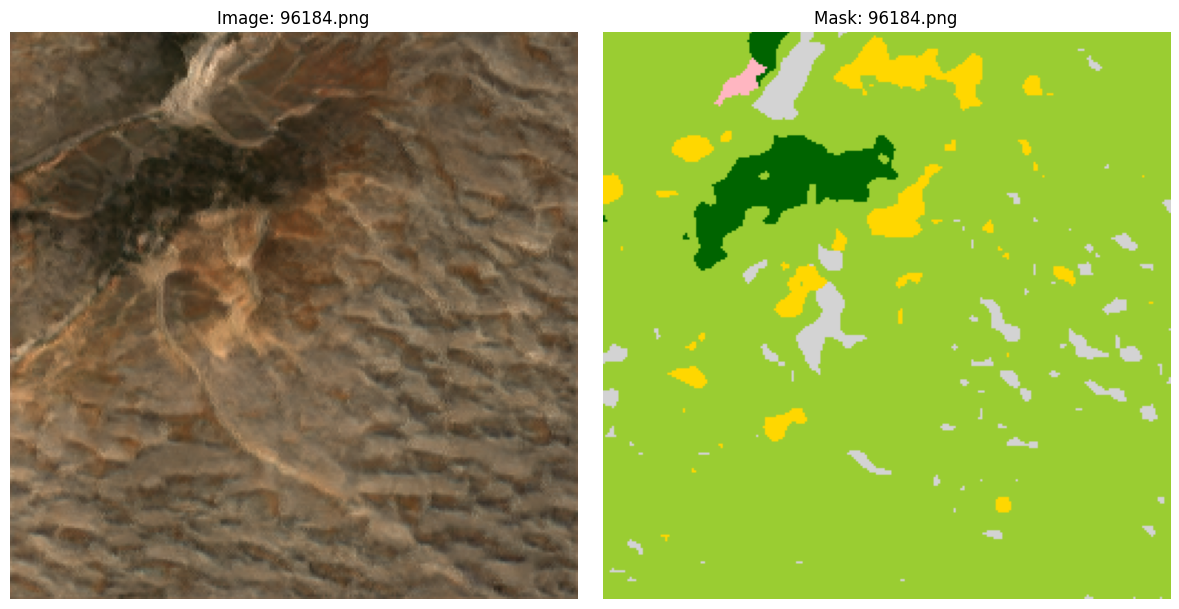

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Get a random file name
sample_file = random.choice(os.listdir(IMG_DIR))

# Define paths
img_path = os.path.join(IMG_DIR, sample_file)
mask_path = os.path.join(MASK_DIR, sample_file)

def plot_sample(img_path,mask_path):
    # Load images
    image = Image.open(img_path)
    mask = Image.open(mask_path)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(image)
    axes[0].set_title(f"Image: {sample_file}")
    axes[0].axis('off')

    axes[1].imshow(mask)
    axes[1].set_title(f"Mask: {sample_file}")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
plot_sample(img_path,mask_path)

In [ ]:
COLOR_MAP = {
    (0, 100, 0): 0,        # Tree
    (255, 182, 193): 1,    # Shrub
    (154, 205, 50): 2,     # Grass
    (255, 215, 0): 3,       # Crop
    (139, 69, 19): 4,      # Built-up
    (211, 211, 211): 5,    # Barren
    (0, 0, 255): 6,        # Water
}

CLASS_NAMES = {
    0: "Tree",
    1: "Shrub",
    2: "Grass",
    3: "Crop",
    4: "Built-up",
    5: "Barren",
    6: "Water"
}

# **Training**

In [ ]:
def rgb_to_class_mask(mask_img, color_map):
    """Converts the RGB mask into a 2D tensor consisting of class indices (0–6)."""
    mask_np = np.array(mask_img)
    class_mask = np.zeros((mask_np.shape[0], mask_np.shape[1]), dtype=np.int64)

    for rgb, class_idx in color_map.items():
        matches = (mask_np == rgb).all(axis=-1)
        class_mask[matches] = class_idx
    return torch.tensor(class_mask, dtype=torch.long)

In [ ]:
class MultiModalDataset(Dataset):
    def __init__(self, csv_file, img_dir, mask_dir, tokenizer, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.tokenizer = tokenizer

        # İstatistik sütunları (CSV'deki adlarına tam uygun)
        self.stat_cols = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
        # Metin sütunları (CSV'deki adlarına tam uygun)
        self.text_cols = ['hybrid_gemma3-4b', 'hybrid_qwen3-vl-8b', 'text_qwen3-4b', 'vision_gemma3-4b', 'vision_qwen3-vl-8b']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        filename = row['filename']

        # Image
        img_path = os.path.join(self.img_dir, filename)
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Mask
        mask_path = os.path.join(self.mask_dir, filename)
        mask_img = Image.open(mask_path).convert("RGB")
        # Used NEAREST to prevent pixel distortion when resizing the mask
        mask_img = mask_img.resize((256, 256), Image.NEAREST)
        mask = rgb_to_class_mask(mask_img, COLOR_MAP)

        # 3. Statistics (Normalized the 0–100 range to the 0–1 range)
        stats = row[self.stat_cols].values.astype(np.float32) / 100.0
        stats = torch.tensor(stats)

        # 4. Texts (Combined 5 texts into a single sentence for the Naive Baseline)
        combined_text = " ".join([str(row[col]) for col in self.text_cols])
        text_tokens = self.tokenizer(
            combined_text,
            padding='max_length',
            truncation=True,
            max_length=128,
            return_tensors="pt"
        )

        return {
            "image": image,
            "mask": mask,
            "stats": stats,
            "input_ids": text_tokens["input_ids"].squeeze(0),
            "attention_mask": text_tokens["attention_mask"].squeeze(0)
        }


In [ ]:
class TransformerBaselineModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Vision Backbone (SegFormer mit-b0)
        self.image_encoder = SegformerModel.from_pretrained("nvidia/mit-b0")
        self.vision_dim = 256 # mit-b0'ın son katman çıkış kanal sayısı

        # Text Backbone (Tiny BERT)
        self.text_encoder = AutoModel.from_pretrained("prajjwal1/bert-tiny")
        self.text_proj = nn.Linear(128, 64) # TinyBERT çıkışını 64'e indirgiyoruz

        # Statistical Projection
        self.stat_proj = nn.Linear(7, 64)

        # Fusion Layer: Vision (256) + Text (64) + Stats (64) = 384
        self.decoder = nn.Sequential(
            nn.Conv2d(384, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def forward(self, images, stats, input_ids, attention_mask):
        B, C, H, W = images.shape

        # 1. Image Features -> [B, 256, H/32, W/32]
        img_outputs = self.image_encoder(pixel_values=images)
        img_features = img_outputs.last_hidden_state
        _, _, f_H, f_W = img_features.shape

        # 2. Text Features -> CLS Token-> [B, 64]
        text_outputs = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_cls = text_outputs.last_hidden_state[:, 0, :]
        text_features = F.relu(self.text_proj(text_cls))

        # 3. Statistic Features-> [B, 64]
        stat_features = F.relu(self.stat_proj(stats))

        # 4. Spatial Expansion
        # We copy the text and statistical 1D vectors to the dimensions of the image feature map (f_H, f_W)
        text_spatial = text_features.view(B, 64, 1, 1).expand(-1, -1, f_H, f_W)
        stat_spatial = stat_features.view(B, 64, 1, 1).expand(-1, -1, f_H, f_W)

        # 5. NAIVE FUSION
        fused = torch.cat([img_features, text_spatial, stat_spatial], dim=1) # [B, 384, f_H, f_W]

        # 6. Size Increase
        logits = self.decoder(fused) # [B, 7, f_H, f_W]

        # Restore the mask to its original image size (e.g., 256x256)
        out = F.interpolate(logits, size=(H, W), mode='bilinear', align_corners=False)
        return out

In [ ]:
def calculate_accuracy(preds, masks):
    """Calculates pixel-based accuracy."""
    pred_classes = torch.argmax(preds, dim=1)
    correct = (pred_classes == masks).sum().item()
    total = masks.numel()
    return correct / total


In [ ]:
def train_and_evaluate(epochs=5, batch_size=4, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device used: {device}")

    # Image transformations
    transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor(),
        # Recommended ImageNet normalization for SegFormer and standard models
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    tokenizer = AutoTokenizer.from_pretrained("prajjwal1/bert-tiny")

    # Dataset ve Dataloader
    dataset = MultiModalDataset(CAPTION_DIR, IMG_DIR, MASK_DIR, tokenizer, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = TransformerBaselineModel(num_classes=7).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch_losses = []
    epoch_accs = []

    print("Training Started")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0.0

        for batch_idx, batch in enumerate(dataloader):
            images = batch["image"].to(device)
            masks = batch["mask"].to(device)
            stats = batch["stats"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()

            outputs = model(images, stats, input_ids, attention_mask)

            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            acc = calculate_accuracy(outputs, masks)

            running_loss += loss.item()
            running_acc += acc

            # Print to the console every 10 batches
            if (batch_idx + 1) % 10 == 0:
                print(f"Epoch [{epoch+1}/{epochs}] - Batch [{batch_idx+1}/{len(dataloader)}] - Loss: {loss.item():.4f} - Acc: {acc:.4f}")

        # Average metrics at the end of the epoch
        avg_loss = running_loss / len(dataloader)
        avg_acc = running_acc / len(dataloader)

        epoch_losses.append(avg_loss)
        epoch_accs.append(avg_acc)
        print(f"==> Epoch {epoch+1} Summary: Mean Loss: {avg_loss:.4f} | Mean Pixel Acc: {avg_acc:.4f}\n")

    return model, dataloader, dataset, epoch_losses, epoch_accs

In [ ]:

def plot_metrics(losses, accuracies):
    """
    Clean, readable, and clear charts that comply with data-to-viz guidelines.
    Includes high-contrast colors and distinctive markers suitable for people with color blindness.
    """
    sns.set_theme(style="whitegrid")
    fig, ax1 = plt.subplots(figsize=(10, 5))

    color1 = '#1f77b4' # Blue
    color2 = '#d62728' # Red

    # Left Y axis - Loss
    ax1.set_xlabel('Epochs', fontweight='bold')
    ax1.set_ylabel('CrossEntropy Loss', color=color1, fontweight='bold')
    line1, = ax1.plot(range(1, len(losses)+1), losses, color=color1, marker='o', linewidth=2.5, label='Training Loss')
    ax1.tick_params(axis='y', labelcolor=color1)

    # Right Y axis: Pixel Accuracy
    ax2 = ax1.twinx()
    ax2.set_ylabel('Pixel Accuracy', color=color2, fontweight='bold')
    line2, = ax2.plot(range(1, len(accuracies)+1), accuracies, color=color2, marker='s', linewidth=2.5, linestyle='--', label='Pixel Accuracy')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Baseline Multi-Modal Model Performance (Phase 1)', fontsize=14, fontweight='bold')

    # Legend birleştirme
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=True, shadow=True)

    plt.tight_layout()
    plt.show()



Device used: cuda


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/39 [00:00<?, ?it/s]

BertModel LOAD REPORT from: prajjwal1/bert-tiny
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training Started
Epoch [1/5] - Batch [10/2500] - Loss: 1.7079 - Acc: 0.2889
Epoch [1/5] - Batch [20/2500] - Loss: 1.6773 - Acc: 0.4738
Epoch [1/5] - Batch [30/2500] - Loss: 1.9160 - Acc: 0.2936
Epoch [1/5] - Batch [40/2500] - Loss: 1.2693 - Acc: 0.6689
Epoch [1/5] - Batch [50/2500] - Loss: 1.3154 - Acc: 0.6165
Epoch [1/5] - Batch [60/2500] - Loss: 1.7089 - Acc: 0.4801
Epoch [1/5] - Batch [70/2500] - Loss: 1.0981 - Acc: 0.7550
Epoch [1/5] - Batch [80/2500] - Loss: 1.0056 - Acc: 0.7647
Epoch [1/5] - Batch [90/2500] - Loss: 1.2673 - Acc: 0.7402
Epoch [1/5] - Batch [100/2500] - Loss: 1.1074 - Acc: 0.6514
Epoch [1/5] - Batch [110/2500] - Loss: 1.1469 - Acc: 0.5884
Epoch [1/5] - Batch [120/2500] - Loss: 1.0858 - Acc: 0.5849
Epoch [1/5] - Batch [130/2500] - Loss: 0.8046 - Acc: 0.8553
Epoch [1/5] - Batch [140/2500] - Loss: 0.7622 - Acc: 0.7935
Epoch [1/5] - Batch [150/2500] - Loss: 0.6770 - Acc: 0.8315
Epoch [1/5] - Batch [160/2500] - Loss: 2.0226 - Acc: 0.4680
Epoch [1/5] - Batch [170/2500] -

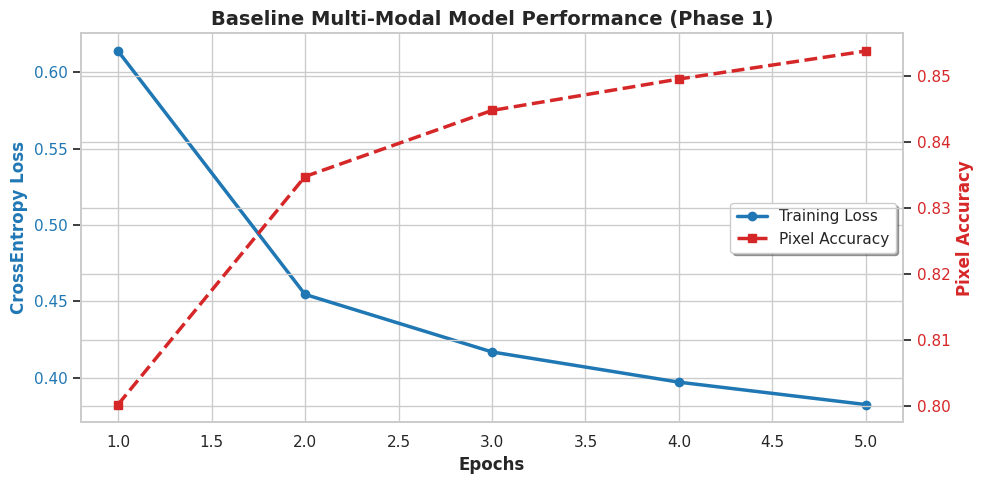

In [ ]:

if __name__ == "__main__":

    model, dataloader, dataset, losses, accs = train_and_evaluate(epochs=5, batch_size=4)
    plot_metrics(losses, accs)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import textwrap

REVERSE_COLOR_MAP = {v: k for k, v in COLOR_MAP.items()}

def decode_segmap(image_tensor, num_classes=7):
    image_numpy = image_tensor.cpu().numpy()
    r = np.zeros_like(image_numpy).astype(np.uint8)
    g = np.zeros_like(image_numpy).astype(np.uint8)
    b = np.zeros_like(image_numpy).astype(np.uint8)
    for class_idx in range(num_classes):
        idx = image_numpy == class_idx
        r[idx] = REVERSE_COLOR_MAP[class_idx][0]
        g[idx] = REVERSE_COLOR_MAP[class_idx][1]
        b[idx] = REVERSE_COLOR_MAP[class_idx][2]
    return np.stack([r, g, b], axis=2)

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = tensor.cpu().numpy().transpose(1, 2, 0)
    image = std * image + mean
    return np.clip(image, 0, 1)


def visualize_complete_dashboard(model, dataloader, dataset):
    """
    Displays the model's image, statistical, and text inputs,
    along with the ground truth and predicted mask, all on a single panel.
    """
    # dynamically select between CUDA, MPS (Mac), or the CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
    model.to(device)
    model.eval()

    # Retrieve a random single batch from Dataloader
    batch = next(iter(dataloader))

    # Set aside only the first element for analysis
    image = batch["image"][0].to(device)
    mask = batch["mask"][0].to(device)
    stats = batch["stats"][0].cpu().numpy() * 100 # Convert to a percentage for plotting on a graph
    input_ids = batch["input_ids"][0].to(device)
    attention_mask = batch["attention_mask"][0].to(device)

    # Run the model (Set the dimensions to [1, C, H, W])
    with torch.no_grad():
        output = model(
            image.unsqueeze(0),
            batch["stats"][0:1].to(device),
            input_ids.unsqueeze(0),
            attention_mask.unsqueeze(0)
        )
        pred = torch.argmax(output, dim=1)[0]

    # Convert tokens to readable text (if a tokenizer is defined)
    try:
        text = dataset.tokenizer.decode(input_ids, skip_special_tokens=True)
    except:
        text = "Couldn find"

    fig = plt.figure(figsize=(16, 9))

    gs = fig.add_gridspec(2, 3, height_ratios=[2.5, 1.2])

    # 1. Original Image (Input 1)
    ax_img = fig.add_subplot(gs[0, 0])
    ax_img.imshow(denormalize(image))
    ax_img.set_title("Image", fontweight='bold', fontsize=12)
    ax_img.axis('off')

    # 2. Ground Truth Mask
    ax_gt = fig.add_subplot(gs[0, 1])
    ax_gt.imshow(decode_segmap(mask))
    ax_gt.set_title(" Ground Truth ", fontweight='bold', fontsize=12)
    ax_gt.axis('off')

    # 3. Model Prediction
    ax_pred = fig.add_subplot(gs[0, 2])
    ax_pred.imshow(decode_segmap(pred))
    ax_pred.set_title("Prediction", fontweight='bold', fontsize=12)
    ax_pred.axis('off')

    # 4. Statistics Bar (Input 2)
    ax_stat = fig.add_subplot(gs[1, 0])
    classes = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']

    # To use RGB colors in a graphic, we convert them to HEX format
    colors = ['#006400', '#FFB6C1', '#9ACD32', '#FFD700', '#8B4513', '#D3D3D3', '#0000FF']

    ax_stat.bar(classes, stats, color=colors, edgecolor='black', alpha=0.8)
    ax_stat.set_ylim(0, 100)
    ax_stat.set_ylabel("Percentage (%)", fontweight='bold')
    ax_stat.set_title("Class Distributions ", fontweight='bold')
    ax_stat.tick_params(axis='x', rotation=30)
    ax_stat.grid(axis='y', linestyle='--', alpha=0.7)

    # 5. Text Box (Input 3)
    ax_text = fig.add_subplot(gs[1, 1:3])
    ax_text.axis('off')
    wrapped_text = textwrap.fill(text, width=110)

    ax_text.text(0.02, 0.5, f"Text Input (Captions):\n\n{wrapped_text}",
                 fontsize=11, va='center', ha='left', wrap=True,
                 bbox=dict(boxstyle="round,pad=1.2", fc="#f8f9fa", ec="#ced4da", lw=1.5))
    ax_text.set_title("Language Model Summary", fontweight='bold')

    plt.tight_layout()
    plt.show()


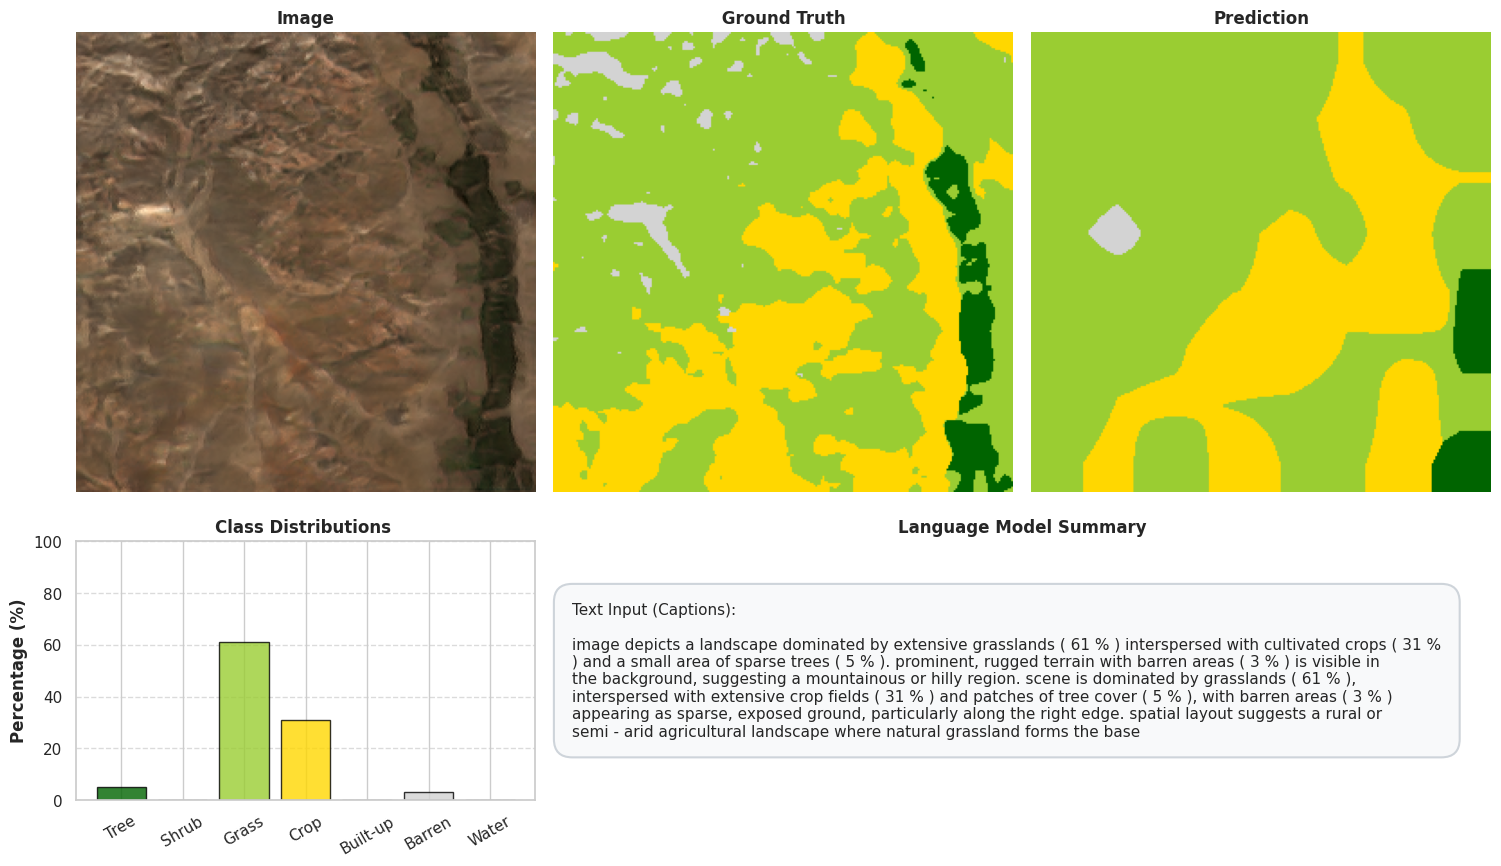

In [ ]:
visualize_complete_dashboard(model, dataloader, dataset)

In [ ]:
pip install wandb


In [ ]:
import wandb
import re
wandb.login()


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: aleynakirmizi11 (aleynakirmizi11-middle-east-technical-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="aleynakirmizi11-middle-east-technical-university",
    # Set the wandb project where this run will be logged.
    project="Baseline Model",
    # Track hyperparameters and run metadata.
)

In [ ]:


# 1. wandb'yi başlat

# 2. Elindeki BÜTÜN çıktı metnini üç tırnak arasına yapıştır
raw_logs = """
Epoch [1/5] - Batch [10/2500] - Loss: 1.7079 - Acc: 0.2889
Epoch [1/5] - Batch [20/2500] - Loss: 1.6773 - Acc: 0.4738
Epoch [1/5] - Batch [30/2500] - Loss: 1.9160 - Acc: 0.2936
Epoch [1/5] - Batch [40/2500] - Loss: 1.2693 - Acc: 0.6689
Epoch [1/5] - Batch [50/2500] - Loss: 1.3154 - Acc: 0.6165
Epoch [1/5] - Batch [60/2500] - Loss: 1.7089 - Acc: 0.4801
Epoch [1/5] - Batch [70/2500] - Loss: 1.0981 - Acc: 0.7550
Epoch [1/5] - Batch [80/2500] - Loss: 1.0056 - Acc: 0.7647
Epoch [1/5] - Batch [90/2500] - Loss: 1.2673 - Acc: 0.7402
Epoch [1/5] - Batch [100/2500] - Loss: 1.1074 - Acc: 0.6514
Epoch [1/5] - Batch [110/2500] - Loss: 1.1469 - Acc: 0.5884
Epoch [1/5] - Batch [120/2500] - Loss: 1.0858 - Acc: 0.5849
Epoch [1/5] - Batch [130/2500] - Loss: 0.8046 - Acc: 0.8553
Epoch [1/5] - Batch [140/2500] - Loss: 0.7622 - Acc: 0.7935
Epoch [1/5] - Batch [150/2500] - Loss: 0.6770 - Acc: 0.8315
Epoch [1/5] - Batch [160/2500] - Loss: 2.0226 - Acc: 0.4680
Epoch [1/5] - Batch [170/2500] - Loss: 1.1836 - Acc: 0.6194
Epoch [1/5] - Batch [180/2500] - Loss: 1.3430 - Acc: 0.5957
Epoch [1/5] - Batch [190/2500] - Loss: 1.1936 - Acc: 0.6893
Epoch [1/5] - Batch [200/2500] - Loss: 0.8415 - Acc: 0.7435
Epoch [1/5] - Batch [210/2500] - Loss: 0.6145 - Acc: 0.8803
Epoch [1/5] - Batch [220/2500] - Loss: 0.7913 - Acc: 0.8017
Epoch [1/5] - Batch [230/2500] - Loss: 0.7749 - Acc: 0.8274
Epoch [1/5] - Batch [240/2500] - Loss: 1.0084 - Acc: 0.7395
Epoch [1/5] - Batch [250/2500] - Loss: 0.5347 - Acc: 0.8752
Epoch [1/5] - Batch [260/2500] - Loss: 0.7916 - Acc: 0.7702
Epoch [1/5] - Batch [270/2500] - Loss: 0.6059 - Acc: 0.8428
Epoch [1/5] - Batch [280/2500] - Loss: 0.7900 - Acc: 0.7775
Epoch [1/5] - Batch [290/2500] - Loss: 0.7669 - Acc: 0.8002
Epoch [1/5] - Batch [300/2500] - Loss: 1.0195 - Acc: 0.6562
Epoch [1/5] - Batch [310/2500] - Loss: 0.8938 - Acc: 0.7200
Epoch [1/5] - Batch [320/2500] - Loss: 0.6857 - Acc: 0.7920
Epoch [1/5] - Batch [330/2500] - Loss: 0.4901 - Acc: 0.8834
Epoch [1/5] - Batch [340/2500] - Loss: 0.8531 - Acc: 0.7949
Epoch [1/5] - Batch [350/2500] - Loss: 0.6289 - Acc: 0.8278
Epoch [1/5] - Batch [360/2500] - Loss: 0.6524 - Acc: 0.8130
Epoch [1/5] - Batch [370/2500] - Loss: 0.4256 - Acc: 0.8930
Epoch [1/5] - Batch [380/2500] - Loss: 0.6940 - Acc: 0.7685
Epoch [1/5] - Batch [390/2500] - Loss: 0.7643 - Acc: 0.7329
Epoch [1/5] - Batch [400/2500] - Loss: 0.5669 - Acc: 0.8087
Epoch [1/5] - Batch [410/2500] - Loss: 0.7089 - Acc: 0.8276
Epoch [1/5] - Batch [420/2500] - Loss: 0.5022 - Acc: 0.9092
Epoch [1/5] - Batch [430/2500] - Loss: 0.7773 - Acc: 0.7569
Epoch [1/5] - Batch [440/2500] - Loss: 0.7019 - Acc: 0.8016
Epoch [1/5] - Batch [450/2500] - Loss: 0.6784 - Acc: 0.7576
Epoch [1/5] - Batch [460/2500] - Loss: 0.8833 - Acc: 0.7194
Epoch [1/5] - Batch [470/2500] - Loss: 0.8665 - Acc: 0.7716
Epoch [1/5] - Batch [480/2500] - Loss: 0.9193 - Acc: 0.6683
Epoch [1/5] - Batch [490/2500] - Loss: 0.5797 - Acc: 0.8216
Epoch [1/5] - Batch [500/2500] - Loss: 0.5153 - Acc: 0.8328
Epoch [1/5] - Batch [510/2500] - Loss: 0.4684 - Acc: 0.8778
Epoch [1/5] - Batch [520/2500] - Loss: 0.7044 - Acc: 0.7268
Epoch [1/5] - Batch [530/2500] - Loss: 0.8843 - Acc: 0.6891
Epoch [1/5] - Batch [540/2500] - Loss: 0.7208 - Acc: 0.7833
Epoch [1/5] - Batch [550/2500] - Loss: 0.5102 - Acc: 0.8407
Epoch [1/5] - Batch [560/2500] - Loss: 0.7760 - Acc: 0.7307
Epoch [1/5] - Batch [570/2500] - Loss: 0.6976 - Acc: 0.7906
Epoch [1/5] - Batch [580/2500] - Loss: 0.5887 - Acc: 0.8214
Epoch [1/5] - Batch [590/2500] - Loss: 0.7723 - Acc: 0.7462
Epoch [1/5] - Batch [600/2500] - Loss: 0.9130 - Acc: 0.7894
Epoch [1/5] - Batch [610/2500] - Loss: 0.8139 - Acc: 0.7647
Epoch [1/5] - Batch [620/2500] - Loss: 0.9653 - Acc: 0.6974
Epoch [1/5] - Batch [630/2500] - Loss: 0.4614 - Acc: 0.8778
Epoch [1/5] - Batch [640/2500] - Loss: 0.5804 - Acc: 0.8190
Epoch [1/5] - Batch [650/2500] - Loss: 1.1315 - Acc: 0.5094
Epoch [1/5] - Batch [660/2500] - Loss: 0.6339 - Acc: 0.8562
Epoch [1/5] - Batch [670/2500] - Loss: 0.6196 - Acc: 0.8516
Epoch [1/5] - Batch [680/2500] - Loss: 0.2895 - Acc: 0.9179
Epoch [1/5] - Batch [690/2500] - Loss: 0.5151 - Acc: 0.8788
Epoch [1/5] - Batch [700/2500] - Loss: 0.7413 - Acc: 0.7390
Epoch [1/5] - Batch [710/2500] - Loss: 0.7551 - Acc: 0.7498
Epoch [1/5] - Batch [720/2500] - Loss: 0.4704 - Acc: 0.8431
Epoch [1/5] - Batch [730/2500] - Loss: 0.4973 - Acc: 0.8218
Epoch [1/5] - Batch [740/2500] - Loss: 0.8369 - Acc: 0.7804
Epoch [1/5] - Batch [750/2500] - Loss: 0.6536 - Acc: 0.7683
Epoch [1/5] - Batch [760/2500] - Loss: 0.5654 - Acc: 0.8249
Epoch [1/5] - Batch [770/2500] - Loss: 0.6830 - Acc: 0.8286
Epoch [1/5] - Batch [780/2500] - Loss: 0.3696 - Acc: 0.9457
Epoch [1/5] - Batch [790/2500] - Loss: 0.5831 - Acc: 0.8592
Epoch [1/5] - Batch [800/2500] - Loss: 0.5271 - Acc: 0.8748
Epoch [1/5] - Batch [810/2500] - Loss: 0.4755 - Acc: 0.8538
Epoch [1/5] - Batch [820/2500] - Loss: 0.5628 - Acc: 0.7927
Epoch [1/5] - Batch [830/2500] - Loss: 0.4841 - Acc: 0.8783
Epoch [1/5] - Batch [840/2500] - Loss: 0.6254 - Acc: 0.8305
Epoch [1/5] - Batch [850/2500] - Loss: 0.4232 - Acc: 0.8452
Epoch [1/5] - Batch [860/2500] - Loss: 0.4241 - Acc: 0.8829
Epoch [1/5] - Batch [870/2500] - Loss: 0.9286 - Acc: 0.7124
Epoch [1/5] - Batch [880/2500] - Loss: 0.4019 - Acc: 0.8645
Epoch [1/5] - Batch [890/2500] - Loss: 0.6779 - Acc: 0.7408
Epoch [1/5] - Batch [900/2500] - Loss: 0.4631 - Acc: 0.8658
Epoch [1/5] - Batch [910/2500] - Loss: 0.3689 - Acc: 0.8968
Epoch [1/5] - Batch [920/2500] - Loss: 0.3894 - Acc: 0.8864
Epoch [1/5] - Batch [930/2500] - Loss: 0.4470 - Acc: 0.8423
Epoch [1/5] - Batch [940/2500] - Loss: 0.4720 - Acc: 0.8514
Epoch [1/5] - Batch [950/2500] - Loss: 0.3813 - Acc: 0.8811
Epoch [1/5] - Batch [960/2500] - Loss: 0.6015 - Acc: 0.8429
Epoch [1/5] - Batch [970/2500] - Loss: 0.8481 - Acc: 0.7281
Epoch [1/5] - Batch [980/2500] - Loss: 0.3726 - Acc: 0.8766
Epoch [1/5] - Batch [990/2500] - Loss: 0.4550 - Acc: 0.8224
Epoch [1/5] - Batch [1000/2500] - Loss: 0.4117 - Acc: 0.8877
Epoch [1/5] - Batch [1010/2500] - Loss: 0.4018 - Acc: 0.8575
Epoch [1/5] - Batch [1020/2500] - Loss: 0.3743 - Acc: 0.9009
Epoch [1/5] - Batch [1030/2500] - Loss: 0.6062 - Acc: 0.7731
Epoch [1/5] - Batch [1040/2500] - Loss: 0.7418 - Acc: 0.6908
Epoch [1/5] - Batch [1050/2500] - Loss: 0.4237 - Acc: 0.9164
Epoch [1/5] - Batch [1060/2500] - Loss: 0.4613 - Acc: 0.8628
Epoch [1/5] - Batch [1070/2500] - Loss: 0.4531 - Acc: 0.8410
Epoch [1/5] - Batch [1080/2500] - Loss: 0.6346 - Acc: 0.7687
Epoch [1/5] - Batch [1090/2500] - Loss: 0.4722 - Acc: 0.8426
Epoch [1/5] - Batch [1100/2500] - Loss: 0.4628 - Acc: 0.8151
Epoch [1/5] - Batch [1110/2500] - Loss: 0.3843 - Acc: 0.9107
Epoch [1/5] - Batch [1120/2500] - Loss: 0.6824 - Acc: 0.7784
Epoch [1/5] - Batch [1130/2500] - Loss: 0.7459 - Acc: 0.7594
Epoch [1/5] - Batch [1140/2500] - Loss: 0.6019 - Acc: 0.7829
Epoch [1/5] - Batch [1150/2500] - Loss: 0.6562 - Acc: 0.7696
Epoch [1/5] - Batch [1160/2500] - Loss: 0.6719 - Acc: 0.7928
Epoch [1/5] - Batch [1170/2500] - Loss: 0.3704 - Acc: 0.8977
Epoch [1/5] - Batch [1180/2500] - Loss: 0.2816 - Acc: 0.9280
Epoch [1/5] - Batch [1190/2500] - Loss: 0.4575 - Acc: 0.8682
Epoch [1/5] - Batch [1200/2500] - Loss: 0.7384 - Acc: 0.7262
Epoch [1/5] - Batch [1210/2500] - Loss: 0.7106 - Acc: 0.7745
Epoch [1/5] - Batch [1220/2500] - Loss: 0.4114 - Acc: 0.8742
Epoch [1/5] - Batch [1230/2500] - Loss: 0.3991 - Acc: 0.8606
Epoch [1/5] - Batch [1240/2500] - Loss: 0.5073 - Acc: 0.8105
Epoch [1/5] - Batch [1250/2500] - Loss: 0.5693 - Acc: 0.7447
Epoch [1/5] - Batch [1260/2500] - Loss: 0.3341 - Acc: 0.8661
Epoch [1/5] - Batch [1270/2500] - Loss: 0.6653 - Acc: 0.7456
Epoch [1/5] - Batch [1280/2500] - Loss: 0.3089 - Acc: 0.9158
Epoch [1/5] - Batch [1290/2500] - Loss: 1.3938 - Acc: 0.6198
Epoch [1/5] - Batch [1300/2500] - Loss: 0.7442 - Acc: 0.7828
Epoch [1/5] - Batch [1310/2500] - Loss: 0.5636 - Acc: 0.8046
Epoch [1/5] - Batch [1320/2500] - Loss: 0.7603 - Acc: 0.7029
Epoch [1/5] - Batch [1330/2500] - Loss: 0.5872 - Acc: 0.7904
Epoch [1/5] - Batch [1340/2500] - Loss: 0.4087 - Acc: 0.8599
Epoch [1/5] - Batch [1350/2500] - Loss: 0.6225 - Acc: 0.7868
Epoch [1/5] - Batch [1360/2500] - Loss: 0.6235 - Acc: 0.7754
Epoch [1/5] - Batch [1370/2500] - Loss: 0.5283 - Acc: 0.8012
Epoch [1/5] - Batch [1380/2500] - Loss: 0.5965 - Acc: 0.8236
Epoch [1/5] - Batch [1390/2500] - Loss: 0.3669 - Acc: 0.8894
Epoch [1/5] - Batch [1400/2500] - Loss: 0.6109 - Acc: 0.7532
Epoch [1/5] - Batch [1410/2500] - Loss: 0.3389 - Acc: 0.9029
Epoch [1/5] - Batch [1420/2500] - Loss: 0.6071 - Acc: 0.8032
Epoch [1/5] - Batch [1430/2500] - Loss: 0.5692 - Acc: 0.8084
Epoch [1/5] - Batch [1440/2500] - Loss: 0.4569 - Acc: 0.8474
Epoch [1/5] - Batch [1450/2500] - Loss: 0.4868 - Acc: 0.8238
Epoch [1/5] - Batch [1460/2500] - Loss: 0.8038 - Acc: 0.6673
Epoch [1/5] - Batch [1470/2500] - Loss: 0.3100 - Acc: 0.9152
Epoch [1/5] - Batch [1480/2500] - Loss: 0.4404 - Acc: 0.8713
Epoch [1/5] - Batch [1490/2500] - Loss: 0.4345 - Acc: 0.8644
Epoch [1/5] - Batch [1500/2500] - Loss: 0.3391 - Acc: 0.8964
Epoch [1/5] - Batch [1510/2500] - Loss: 0.6053 - Acc: 0.7301
Epoch [1/5] - Batch [1520/2500] - Loss: 0.6259 - Acc: 0.7916
Epoch [1/5] - Batch [1530/2500] - Loss: 0.6911 - Acc: 0.7791
Epoch [1/5] - Batch [1540/2500] - Loss: 0.3553 - Acc: 0.9012
Epoch [1/5] - Batch [1550/2500] - Loss: 0.4052 - Acc: 0.8758
Epoch [1/5] - Batch [1560/2500] - Loss: 0.5295 - Acc: 0.8034
Epoch [1/5] - Batch [1570/2500] - Loss: 0.4111 - Acc: 0.8839
Epoch [1/5] - Batch [1580/2500] - Loss: 0.9127 - Acc: 0.6681
Epoch [1/5] - Batch [1590/2500] - Loss: 0.5180 - Acc: 0.8123
Epoch [1/5] - Batch [1600/2500] - Loss: 0.3146 - Acc: 0.8830
Epoch [1/5] - Batch [1610/2500] - Loss: 0.3608 - Acc: 0.8820
Epoch [1/5] - Batch [1620/2500] - Loss: 0.3533 - Acc: 0.8736
Epoch [1/5] - Batch [1630/2500] - Loss: 0.7167 - Acc: 0.7814
Epoch [1/5] - Batch [1640/2500] - Loss: 0.5598 - Acc: 0.8279
Epoch [1/5] - Batch [1650/2500] - Loss: 0.4610 - Acc: 0.8417
Epoch [1/5] - Batch [1660/2500] - Loss: 0.5624 - Acc: 0.7857
Epoch [1/5] - Batch [1670/2500] - Loss: 0.5971 - Acc: 0.7670
Epoch [1/5] - Batch [1680/2500] - Loss: 0.5624 - Acc: 0.7638
Epoch [1/5] - Batch [1690/2500] - Loss: 0.8351 - Acc: 0.7624
Epoch [1/5] - Batch [1700/2500] - Loss: 0.6161 - Acc: 0.8252
Epoch [1/5] - Batch [1710/2500] - Loss: 0.5504 - Acc: 0.7610
Epoch [1/5] - Batch [1720/2500] - Loss: 0.2949 - Acc: 0.9275
Epoch [1/5] - Batch [1730/2500] - Loss: 0.5019 - Acc: 0.8312
Epoch [1/5] - Batch [1740/2500] - Loss: 0.4525 - Acc: 0.8260
Epoch [1/5] - Batch [1750/2500] - Loss: 0.4429 - Acc: 0.8415
Epoch [1/5] - Batch [1760/2500] - Loss: 0.3633 - Acc: 0.8890
Epoch [1/5] - Batch [1770/2500] - Loss: 0.4357 - Acc: 0.8413
Epoch [1/5] - Batch [1780/2500] - Loss: 0.4939 - Acc: 0.8276
Epoch [1/5] - Batch [1790/2500] - Loss: 1.0121 - Acc: 0.7764
Epoch [1/5] - Batch [1800/2500] - Loss: 0.4158 - Acc: 0.8281
Epoch [1/5] - Batch [1810/2500] - Loss: 0.6278 - Acc: 0.7805
Epoch [1/5] - Batch [1820/2500] - Loss: 0.4227 - Acc: 0.8480
Epoch [1/5] - Batch [1830/2500] - Loss: 0.5504 - Acc: 0.8217
Epoch [1/5] - Batch [1840/2500] - Loss: 0.5328 - Acc: 0.7833
Epoch [1/5] - Batch [1850/2500] - Loss: 0.5855 - Acc: 0.7445
Epoch [1/5] - Batch [1860/2500] - Loss: 1.1181 - Acc: 0.3762
Epoch [1/5] - Batch [1870/2500] - Loss: 0.4303 - Acc: 0.8440
Epoch [1/5] - Batch [1880/2500] - Loss: 0.4480 - Acc: 0.8330
Epoch [1/5] - Batch [1890/2500] - Loss: 0.6899 - Acc: 0.7375
Epoch [1/5] - Batch [1900/2500] - Loss: 0.5829 - Acc: 0.7968
Epoch [1/5] - Batch [1910/2500] - Loss: 0.5204 - Acc: 0.8116
Epoch [1/5] - Batch [1920/2500] - Loss: 0.3384 - Acc: 0.9038
Epoch [1/5] - Batch [1930/2500] - Loss: 0.3629 - Acc: 0.8605
Epoch [1/5] - Batch [1940/2500] - Loss: 0.5946 - Acc: 0.7999
Epoch [1/5] - Batch [1950/2500] - Loss: 0.5105 - Acc: 0.8161
Epoch [1/5] - Batch [1960/2500] - Loss: 0.3928 - Acc: 0.8230
Epoch [1/5] - Batch [1970/2500] - Loss: 0.5247 - Acc: 0.8053
Epoch [1/5] - Batch [1980/2500] - Loss: 0.4227 - Acc: 0.8269
Epoch [1/5] - Batch [1990/2500] - Loss: 0.5495 - Acc: 0.7922
Epoch [1/5] - Batch [2000/2500] - Loss: 0.7528 - Acc: 0.7413
Epoch [1/5] - Batch [2010/2500] - Loss: 0.3820 - Acc: 0.8666
Epoch [1/5] - Batch [2020/2500] - Loss: 0.3138 - Acc: 0.9121
Epoch [1/5] - Batch [2030/2500] - Loss: 0.2634 - Acc: 0.9142
Epoch [1/5] - Batch [2040/2500] - Loss: 0.5283 - Acc: 0.8236
Epoch [1/5] - Batch [2050/2500] - Loss: 0.7690 - Acc: 0.7679
Epoch [1/5] - Batch [2060/2500] - Loss: 0.5666 - Acc: 0.8117
Epoch [1/5] - Batch [2070/2500] - Loss: 0.6095 - Acc: 0.7612
Epoch [1/5] - Batch [2080/2500] - Loss: 0.5405 - Acc: 0.8596
Epoch [1/5] - Batch [2090/2500] - Loss: 0.8076 - Acc: 0.7854
Epoch [1/5] - Batch [2100/2500] - Loss: 0.4158 - Acc: 0.8661
Epoch [1/5] - Batch [2110/2500] - Loss: 0.4721 - Acc: 0.8024
Epoch [1/5] - Batch [2120/2500] - Loss: 0.2846 - Acc: 0.9012
Epoch [1/5] - Batch [2130/2500] - Loss: 0.2850 - Acc: 0.8955
Epoch [1/5] - Batch [2140/2500] - Loss: 0.3579 - Acc: 0.8906
Epoch [1/5] - Batch [2150/2500] - Loss: 0.5756 - Acc: 0.7868
Epoch [1/5] - Batch [2160/2500] - Loss: 0.5907 - Acc: 0.8052
Epoch [1/5] - Batch [2170/2500] - Loss: 0.8863 - Acc: 0.6714
Epoch [1/5] - Batch [2180/2500] - Loss: 0.3865 - Acc: 0.8525
Epoch [1/5] - Batch [2190/2500] - Loss: 0.2898 - Acc: 0.8943
Epoch [1/5] - Batch [2200/2500] - Loss: 0.3176 - Acc: 0.8938
Epoch [1/5] - Batch [2210/2500] - Loss: 0.3967 - Acc: 0.8939
Epoch [1/5] - Batch [2220/2500] - Loss: 0.5879 - Acc: 0.7801
Epoch [1/5] - Batch [2230/2500] - Loss: 0.5607 - Acc: 0.8089
Epoch [1/5] - Batch [2240/2500] - Loss: 0.2610 - Acc: 0.9307
Epoch [1/5] - Batch [2250/2500] - Loss: 0.5890 - Acc: 0.8228
Epoch [1/5] - Batch [2260/2500] - Loss: 0.3229 - Acc: 0.8879
Epoch [1/5] - Batch [2270/2500] - Loss: 0.5089 - Acc: 0.7935
Epoch [1/5] - Batch [2280/2500] - Loss: 0.3864 - Acc: 0.8607
Epoch [1/5] - Batch [2290/2500] - Loss: 0.7710 - Acc: 0.7950
Epoch [1/5] - Batch [2300/2500] - Loss: 0.6598 - Acc: 0.7777
Epoch [1/5] - Batch [2310/2500] - Loss: 0.6527 - Acc: 0.7454
Epoch [1/5] - Batch [2320/2500] - Loss: 0.3220 - Acc: 0.8728
Epoch [1/5] - Batch [2330/2500] - Loss: 0.6576 - Acc: 0.7736
Epoch [1/5] - Batch [2340/2500] - Loss: 0.4549 - Acc: 0.8337
Epoch [1/5] - Batch [2350/2500] - Loss: 0.4952 - Acc: 0.8481
Epoch [1/5] - Batch [2360/2500] - Loss: 0.4547 - Acc: 0.8158
Epoch [1/5] - Batch [2370/2500] - Loss: 0.5183 - Acc: 0.8353
Epoch [1/5] - Batch [2380/2500] - Loss: 0.5554 - Acc: 0.7937
Epoch [1/5] - Batch [2390/2500] - Loss: 0.3490 - Acc: 0.8711
Epoch [1/5] - Batch [2400/2500] - Loss: 0.5079 - Acc: 0.8085
Epoch [1/5] - Batch [2410/2500] - Loss: 0.3439 - Acc: 0.8796
Epoch [1/5] - Batch [2420/2500] - Loss: 0.4476 - Acc: 0.8357
Epoch [1/5] - Batch [2430/2500] - Loss: 0.3967 - Acc: 0.8764
Epoch [1/5] - Batch [2440/2500] - Loss: 0.5611 - Acc: 0.8305
Epoch [1/5] - Batch [2450/2500] - Loss: 0.4320 - Acc: 0.8480
Epoch [1/5] - Batch [2460/2500] - Loss: 0.2272 - Acc: 0.9142
Epoch [1/5] - Batch [2470/2500] - Loss: 0.3917 - Acc: 0.8670
Epoch [1/5] - Batch [2480/2500] - Loss: 0.2573 - Acc: 0.9363
Epoch [1/5] - Batch [2490/2500] - Loss: 0.5114 - Acc: 0.8145
Epoch [1/5] - Batch [2500/2500] - Loss: 0.5328 - Acc: 0.8106
==> Epoch 1 Summary: Mean Loss: 0.6140 | Mean Pixel Acc: 0.8003

Epoch [2/5] - Batch [10/2500] - Loss: 0.6356 - Acc: 0.7868
Epoch [2/5] - Batch [20/2500] - Loss: 0.6732 - Acc: 0.7345
Epoch [2/5] - Batch [30/2500] - Loss: 0.5988 - Acc: 0.8147
Epoch [2/5] - Batch [40/2500] - Loss: 0.4208 - Acc: 0.8377
Epoch [2/5] - Batch [50/2500] - Loss: 0.3587 - Acc: 0.8900
Epoch [2/5] - Batch [60/2500] - Loss: 0.3652 - Acc: 0.8682
Epoch [2/5] - Batch [70/2500] - Loss: 0.7933 - Acc: 0.6531
Epoch [2/5] - Batch [80/2500] - Loss: 0.3375 - Acc: 0.9016
Epoch [2/5] - Batch [90/2500] - Loss: 0.5077 - Acc: 0.8124
Epoch [2/5] - Batch [100/2500] - Loss: 0.3984 - Acc: 0.8605
Epoch [2/5] - Batch [110/2500] - Loss: 0.4009 - Acc: 0.8673
Epoch [2/5] - Batch [120/2500] - Loss: 0.3757 - Acc: 0.8464
Epoch [2/5] - Batch [130/2500] - Loss: 0.4359 - Acc: 0.8688
Epoch [2/5] - Batch [140/2500] - Loss: 0.5300 - Acc: 0.7904
Epoch [2/5] - Batch [150/2500] - Loss: 0.7132 - Acc: 0.7328
Epoch [2/5] - Batch [160/2500] - Loss: 0.3401 - Acc: 0.8843
Epoch [2/5] - Batch [170/2500] - Loss: 0.4384 - Acc: 0.8492
Epoch [2/5] - Batch [180/2500] - Loss: 0.5966 - Acc: 0.7390
Epoch [2/5] - Batch [190/2500] - Loss: 0.7609 - Acc: 0.6558
Epoch [2/5] - Batch [200/2500] - Loss: 0.3463 - Acc: 0.8618
Epoch [2/5] - Batch [210/2500] - Loss: 0.2645 - Acc: 0.9045
Epoch [2/5] - Batch [220/2500] - Loss: 0.4595 - Acc: 0.8427
Epoch [2/5] - Batch [230/2500] - Loss: 0.6064 - Acc: 0.7686
Epoch [2/5] - Batch [240/2500] - Loss: 0.5257 - Acc: 0.7849
Epoch [2/5] - Batch [250/2500] - Loss: 0.6742 - Acc: 0.7429
Epoch [2/5] - Batch [260/2500] - Loss: 0.3533 - Acc: 0.8768
Epoch [2/5] - Batch [270/2500] - Loss: 0.6089 - Acc: 0.7727
Epoch [2/5] - Batch [280/2500] - Loss: 0.5559 - Acc: 0.8257
Epoch [2/5] - Batch [290/2500] - Loss: 0.4074 - Acc: 0.8500
Epoch [2/5] - Batch [300/2500] - Loss: 0.2039 - Acc: 0.9470
Epoch [2/5] - Batch [310/2500] - Loss: 0.2825 - Acc: 0.9103
Epoch [2/5] - Batch [320/2500] - Loss: 0.3458 - Acc: 0.8798
Epoch [2/5] - Batch [330/2500] - Loss: 0.3665 - Acc: 0.8649
Epoch [2/5] - Batch [340/2500] - Loss: 0.2808 - Acc: 0.9125
Epoch [2/5] - Batch [350/2500] - Loss: 1.1678 - Acc: 0.6662
Epoch [2/5] - Batch [360/2500] - Loss: 0.4424 - Acc: 0.8058
Epoch [2/5] - Batch [370/2500] - Loss: 0.4156 - Acc: 0.8828
Epoch [2/5] - Batch [380/2500] - Loss: 0.4266 - Acc: 0.8341
Epoch [2/5] - Batch [390/2500] - Loss: 0.4007 - Acc: 0.8608
Epoch [2/5] - Batch [400/2500] - Loss: 0.4025 - Acc: 0.8431
Epoch [2/5] - Batch [410/2500] - Loss: 0.4602 - Acc: 0.8046
Epoch [2/5] - Batch [420/2500] - Loss: 0.3817 - Acc: 0.9036
Epoch [2/5] - Batch [430/2500] - Loss: 0.4316 - Acc: 0.8505
Epoch [2/5] - Batch [440/2500] - Loss: 0.5224 - Acc: 0.7640
Epoch [2/5] - Batch [450/2500] - Loss: 0.5901 - Acc: 0.8550
Epoch [2/5] - Batch [460/2500] - Loss: 0.3451 - Acc: 0.8759
Epoch [2/5] - Batch [470/2500] - Loss: 0.4576 - Acc: 0.8373
Epoch [2/5] - Batch [480/2500] - Loss: 0.3800 - Acc: 0.9016
Epoch [2/5] - Batch [490/2500] - Loss: 0.5688 - Acc: 0.7771
Epoch [2/5] - Batch [500/2500] - Loss: 0.3349 - Acc: 0.8731
Epoch [2/5] - Batch [510/2500] - Loss: 0.4379 - Acc: 0.8445
Epoch [2/5] - Batch [520/2500] - Loss: 0.5033 - Acc: 0.7734
Epoch [2/5] - Batch [530/2500] - Loss: 0.4932 - Acc: 0.8214
Epoch [2/5] - Batch [540/2500] - Loss: 0.4498 - Acc: 0.8412
Epoch [2/5] - Batch [550/2500] - Loss: 0.4574 - Acc: 0.8284
Epoch [2/5] - Batch [560/2500] - Loss: 0.3122 - Acc: 0.8995
Epoch [2/5] - Batch [570/2500] - Loss: 0.5697 - Acc: 0.7571
Epoch [2/5] - Batch [580/2500] - Loss: 0.5595 - Acc: 0.7869
Epoch [2/5] - Batch [590/2500] - Loss: 0.5814 - Acc: 0.7879
Epoch [2/5] - Batch [600/2500] - Loss: 0.3767 - Acc: 0.8808
Epoch [2/5] - Batch [610/2500] - Loss: 0.3745 - Acc: 0.8598
Epoch [2/5] - Batch [620/2500] - Loss: 1.6963 - Acc: 0.1587
Epoch [2/5] - Batch [630/2500] - Loss: 0.5878 - Acc: 0.7950
Epoch [2/5] - Batch [640/2500] - Loss: 0.4129 - Acc: 0.8444
Epoch [2/5] - Batch [650/2500] - Loss: 0.3977 - Acc: 0.8531
Epoch [2/5] - Batch [660/2500] - Loss: 0.5087 - Acc: 0.8141
Epoch [2/5] - Batch [670/2500] - Loss: 0.3965 - Acc: 0.8561
Epoch [2/5] - Batch [680/2500] - Loss: 0.3488 - Acc: 0.8848
Epoch [2/5] - Batch [690/2500] - Loss: 0.4781 - Acc: 0.8023
Epoch [2/5] - Batch [700/2500] - Loss: 0.3936 - Acc: 0.8566
Epoch [2/5] - Batch [710/2500] - Loss: 0.4608 - Acc: 0.8241
Epoch [2/5] - Batch [720/2500] - Loss: 0.5162 - Acc: 0.8315
Epoch [2/5] - Batch [730/2500] - Loss: 0.4121 - Acc: 0.9068
Epoch [2/5] - Batch [740/2500] - Loss: 0.5208 - Acc: 0.7937
Epoch [2/5] - Batch [750/2500] - Loss: 0.7060 - Acc: 0.7152
Epoch [2/5] - Batch [760/2500] - Loss: 0.3255 - Acc: 0.9305
Epoch [2/5] - Batch [770/2500] - Loss: 0.2877 - Acc: 0.8951
Epoch [2/5] - Batch [780/2500] - Loss: 0.4128 - Acc: 0.8671
Epoch [2/5] - Batch [790/2500] - Loss: 0.5777 - Acc: 0.7744
Epoch [2/5] - Batch [800/2500] - Loss: 0.2910 - Acc: 0.8909
Epoch [2/5] - Batch [810/2500] - Loss: 0.3389 - Acc: 0.8799
Epoch [2/5] - Batch [820/2500] - Loss: 0.4635 - Acc: 0.8242
Epoch [2/5] - Batch [830/2500] - Loss: 0.2660 - Acc: 0.8979
Epoch [2/5] - Batch [840/2500] - Loss: 0.2353 - Acc: 0.9391
Epoch [2/5] - Batch [850/2500] - Loss: 0.3365 - Acc: 0.8873
Epoch [2/5] - Batch [860/2500] - Loss: 0.3342 - Acc: 0.8882
Epoch [2/5] - Batch [870/2500] - Loss: 0.3955 - Acc: 0.8713
Epoch [2/5] - Batch [880/2500] - Loss: 0.5090 - Acc: 0.8063
Epoch [2/5] - Batch [890/2500] - Loss: 0.3819 - Acc: 0.8676
Epoch [2/5] - Batch [900/2500] - Loss: 0.4320 - Acc: 0.8547
Epoch [2/5] - Batch [910/2500] - Loss: 0.6455 - Acc: 0.7404
Epoch [2/5] - Batch [920/2500] - Loss: 0.5602 - Acc: 0.7791
Epoch [2/5] - Batch [930/2500] - Loss: 0.3918 - Acc: 0.8493
Epoch [2/5] - Batch [940/2500] - Loss: 0.3348 - Acc: 0.8735
Epoch [2/5] - Batch [950/2500] - Loss: 0.3431 - Acc: 0.8753
Epoch [2/5] - Batch [960/2500] - Loss: 0.5120 - Acc: 0.8120
Epoch [2/5] - Batch [970/2500] - Loss: 0.3488 - Acc: 0.8628
Epoch [2/5] - Batch [980/2500] - Loss: 0.5437 - Acc: 0.8229
Epoch [2/5] - Batch [990/2500] - Loss: 0.5509 - Acc: 0.8155
Epoch [2/5] - Batch [1000/2500] - Loss: 0.3640 - Acc: 0.8628
Epoch [2/5] - Batch [1010/2500] - Loss: 0.5365 - Acc: 0.7832
Epoch [2/5] - Batch [1020/2500] - Loss: 0.3830 - Acc: 0.8665
Epoch [2/5] - Batch [1030/2500] - Loss: 0.6638 - Acc: 0.7633
Epoch [2/5] - Batch [1040/2500] - Loss: 0.5022 - Acc: 0.7989
Epoch [2/5] - Batch [1050/2500] - Loss: 0.4691 - Acc: 0.8288
Epoch [2/5] - Batch [1060/2500] - Loss: 0.5619 - Acc: 0.7624
Epoch [2/5] - Batch [1070/2500] - Loss: 0.5108 - Acc: 0.7978
Epoch [2/5] - Batch [1080/2500] - Loss: 0.5028 - Acc: 0.7945
Epoch [2/5] - Batch [1090/2500] - Loss: 0.3166 - Acc: 0.8810
Epoch [2/5] - Batch [1100/2500] - Loss: 0.3441 - Acc: 0.8744
Epoch [2/5] - Batch [1110/2500] - Loss: 0.2094 - Acc: 0.9495
Epoch [2/5] - Batch [1120/2500] - Loss: 0.3816 - Acc: 0.8819
Epoch [2/5] - Batch [1130/2500] - Loss: 0.2305 - Acc: 0.9270
Epoch [2/5] - Batch [1140/2500] - Loss: 0.3855 - Acc: 0.8822
Epoch [2/5] - Batch [1150/2500] - Loss: 0.2191 - Acc: 0.9303
Epoch [2/5] - Batch [1160/2500] - Loss: 0.3768 - Acc: 0.8881
Epoch [2/5] - Batch [1170/2500] - Loss: 0.4548 - Acc: 0.8300
Epoch [2/5] - Batch [1180/2500] - Loss: 0.3558 - Acc: 0.8534
Epoch [2/5] - Batch [1190/2500] - Loss: 0.2373 - Acc: 0.9121
Epoch [2/5] - Batch [1200/2500] - Loss: 0.5379 - Acc: 0.7800
Epoch [2/5] - Batch [1210/2500] - Loss: 0.3044 - Acc: 0.8811
Epoch [2/5] - Batch [1220/2500] - Loss: 0.4001 - Acc: 0.8732
Epoch [2/5] - Batch [1230/2500] - Loss: 0.3690 - Acc: 0.8586
Epoch [2/5] - Batch [1240/2500] - Loss: 0.2554 - Acc: 0.9143
Epoch [2/5] - Batch [1250/2500] - Loss: 0.3601 - Acc: 0.8643
Epoch [2/5] - Batch [1260/2500] - Loss: 0.5473 - Acc: 0.7688
Epoch [2/5] - Batch [1270/2500] - Loss: 0.2792 - Acc: 0.8955
Epoch [2/5] - Batch [1280/2500] - Loss: 0.5137 - Acc: 0.8101
Epoch [2/5] - Batch [1290/2500] - Loss: 0.3501 - Acc: 0.8650
Epoch [2/5] - Batch [1300/2500] - Loss: 0.3099 - Acc: 0.8948
Epoch [2/5] - Batch [1310/2500] - Loss: 0.2326 - Acc: 0.9401
Epoch [2/5] - Batch [1320/2500] - Loss: 0.5628 - Acc: 0.7853
Epoch [2/5] - Batch [1330/2500] - Loss: 0.5535 - Acc: 0.7791
Epoch [2/5] - Batch [1340/2500] - Loss: 0.3153 - Acc: 0.8930
Epoch [2/5] - Batch [1350/2500] - Loss: 0.5302 - Acc: 0.8362
Epoch [2/5] - Batch [1360/2500] - Loss: 0.4720 - Acc: 0.8640
Epoch [2/5] - Batch [1370/2500] - Loss: 1.0670 - Acc: 0.6808
Epoch [2/5] - Batch [1380/2500] - Loss: 0.5394 - Acc: 0.8403
Epoch [2/5] - Batch [1390/2500] - Loss: 1.3282 - Acc: 0.5062
Epoch [2/5] - Batch [1400/2500] - Loss: 0.3957 - Acc: 0.8584
Epoch [2/5] - Batch [1410/2500] - Loss: 0.4862 - Acc: 0.8352
Epoch [2/5] - Batch [1420/2500] - Loss: 0.4699 - Acc: 0.8249
Epoch [2/5] - Batch [1430/2500] - Loss: 0.6998 - Acc: 0.7257
Epoch [2/5] - Batch [1440/2500] - Loss: 0.3790 - Acc: 0.8698
Epoch [2/5] - Batch [1450/2500] - Loss: 0.5478 - Acc: 0.8324
Epoch [2/5] - Batch [1460/2500] - Loss: 0.5814 - Acc: 0.7935
Epoch [2/5] - Batch [1470/2500] - Loss: 0.3202 - Acc: 0.8681
Epoch [2/5] - Batch [1480/2500] - Loss: 0.4446 - Acc: 0.8445
Epoch [2/5] - Batch [1490/2500] - Loss: 0.5268 - Acc: 0.7930
Epoch [2/5] - Batch [1500/2500] - Loss: 1.0976 - Acc: 0.6567
Epoch [2/5] - Batch [1510/2500] - Loss: 0.7382 - Acc: 0.7163
Epoch [2/5] - Batch [1520/2500] - Loss: 0.5047 - Acc: 0.8000
Epoch [2/5] - Batch [1530/2500] - Loss: 0.4192 - Acc: 0.8380
Epoch [2/5] - Batch [1540/2500] - Loss: 0.4086 - Acc: 0.8462
Epoch [2/5] - Batch [1550/2500] - Loss: 0.7283 - Acc: 0.7991
Epoch [2/5] - Batch [1560/2500] - Loss: 0.5747 - Acc: 0.7307
Epoch [2/5] - Batch [1570/2500] - Loss: 0.3694 - Acc: 0.8604
Epoch [2/5] - Batch [1580/2500] - Loss: 0.4659 - Acc: 0.8411
Epoch [2/5] - Batch [1590/2500] - Loss: 0.5224 - Acc: 0.8127
Epoch [2/5] - Batch [1600/2500] - Loss: 0.3911 - Acc: 0.8541
Epoch [2/5] - Batch [1610/2500] - Loss: 0.5793 - Acc: 0.7943
Epoch [2/5] - Batch [1620/2500] - Loss: 0.3977 - Acc: 0.8318
Epoch [2/5] - Batch [1630/2500] - Loss: 0.4989 - Acc: 0.8416
Epoch [2/5] - Batch [1640/2500] - Loss: 0.6956 - Acc: 0.7529
Epoch [2/5] - Batch [1650/2500] - Loss: 0.5310 - Acc: 0.8270
Epoch [2/5] - Batch [1660/2500] - Loss: 0.4778 - Acc: 0.8208
Epoch [2/5] - Batch [1670/2500] - Loss: 0.4052 - Acc: 0.8591
Epoch [2/5] - Batch [1680/2500] - Loss: 0.4783 - Acc: 0.8190
Epoch [2/5] - Batch [1690/2500] - Loss: 0.5084 - Acc: 0.8126
Epoch [2/5] - Batch [1700/2500] - Loss: 0.4483 - Acc: 0.8423
Epoch [2/5] - Batch [1710/2500] - Loss: 0.4025 - Acc: 0.8512
Epoch [2/5] - Batch [1720/2500] - Loss: 0.5969 - Acc: 0.7768
Epoch [2/5] - Batch [1730/2500] - Loss: 0.6240 - Acc: 0.7503
Epoch [2/5] - Batch [1740/2500] - Loss: 0.3149 - Acc: 0.8992
Epoch [2/5] - Batch [1750/2500] - Loss: 0.2408 - Acc: 0.9180
Epoch [2/5] - Batch [1760/2500] - Loss: 0.3669 - Acc: 0.8636
Epoch [2/5] - Batch [1770/2500] - Loss: 0.4129 - Acc: 0.8448
Epoch [2/5] - Batch [1780/2500] - Loss: 0.3457 - Acc: 0.9025
Epoch [2/5] - Batch [1790/2500] - Loss: 0.4951 - Acc: 0.8354
Epoch [2/5] - Batch [1800/2500] - Loss: 0.3775 - Acc: 0.8761
Epoch [2/5] - Batch [1810/2500] - Loss: 0.4441 - Acc: 0.8133
Epoch [2/5] - Batch [1820/2500] - Loss: 0.4040 - Acc: 0.8589
Epoch [2/5] - Batch [1830/2500] - Loss: 0.4353 - Acc: 0.8244
Epoch [2/5] - Batch [1840/2500] - Loss: 0.1441 - Acc: 0.9558
Epoch [2/5] - Batch [1850/2500] - Loss: 0.4833 - Acc: 0.8387
Epoch [2/5] - Batch [1860/2500] - Loss: 0.4749 - Acc: 0.8221
Epoch [2/5] - Batch [1870/2500] - Loss: 0.6390 - Acc: 0.7740
Epoch [2/5] - Batch [1880/2500] - Loss: 0.4384 - Acc: 0.8472
Epoch [2/5] - Batch [1890/2500] - Loss: 0.1798 - Acc: 0.9503
Epoch [2/5] - Batch [1900/2500] - Loss: 0.4276 - Acc: 0.8317
Epoch [2/5] - Batch [1910/2500] - Loss: 0.2891 - Acc: 0.9057
Epoch [2/5] - Batch [1920/2500] - Loss: 0.4368 - Acc: 0.8579
Epoch [2/5] - Batch [1930/2500] - Loss: 0.6866 - Acc: 0.7124
Epoch [2/5] - Batch [1940/2500] - Loss: 0.5917 - Acc: 0.8323
Epoch [2/5] - Batch [1950/2500] - Loss: 0.4165 - Acc: 0.8826
Epoch [2/5] - Batch [1960/2500] - Loss: 0.3644 - Acc: 0.8553
Epoch [2/5] - Batch [1970/2500] - Loss: 0.6182 - Acc: 0.8345
Epoch [2/5] - Batch [1980/2500] - Loss: 0.5376 - Acc: 0.7990
Epoch [2/5] - Batch [1990/2500] - Loss: 0.2190 - Acc: 0.9175
Epoch [2/5] - Batch [2000/2500] - Loss: 0.2682 - Acc: 0.9043
Epoch [2/5] - Batch [2010/2500] - Loss: 0.3051 - Acc: 0.8838
Epoch [2/5] - Batch [2020/2500] - Loss: 0.3980 - Acc: 0.8231
Epoch [2/5] - Batch [2030/2500] - Loss: 0.2804 - Acc: 0.9093
Epoch [2/5] - Batch [2040/2500] - Loss: 0.3246 - Acc: 0.8473
Epoch [2/5] - Batch [2050/2500] - Loss: 0.2965 - Acc: 0.8891
Epoch [2/5] - Batch [2060/2500] - Loss: 0.3950 - Acc: 0.8455
Epoch [2/5] - Batch [2070/2500] - Loss: 0.5382 - Acc: 0.7643
Epoch [2/5] - Batch [2080/2500] - Loss: 0.2738 - Acc: 0.9027
Epoch [2/5] - Batch [2090/2500] - Loss: 0.4324 - Acc: 0.8414
Epoch [2/5] - Batch [2100/2500] - Loss: 0.4932 - Acc: 0.8516
Epoch [2/5] - Batch [2110/2500] - Loss: 0.3109 - Acc: 0.9098
Epoch [2/5] - Batch [2120/2500] - Loss: 0.4987 - Acc: 0.7884
Epoch [2/5] - Batch [2130/2500] - Loss: 0.4586 - Acc: 0.8118
Epoch [2/5] - Batch [2140/2500] - Loss: 0.3275 - Acc: 0.8608
Epoch [2/5] - Batch [2150/2500] - Loss: 0.4527 - Acc: 0.8049
Epoch [2/5] - Batch [2160/2500] - Loss: 0.3713 - Acc: 0.8534
Epoch [2/5] - Batch [2170/2500] - Loss: 0.3973 - Acc: 0.8313
Epoch [2/5] - Batch [2180/2500] - Loss: 0.9018 - Acc: 0.6988
Epoch [2/5] - Batch [2190/2500] - Loss: 0.4253 - Acc: 0.8746
Epoch [2/5] - Batch [2200/2500] - Loss: 0.3464 - Acc: 0.8463
Epoch [2/5] - Batch [2210/2500] - Loss: 0.5005 - Acc: 0.8047
Epoch [2/5] - Batch [2220/2500] - Loss: 0.4862 - Acc: 0.8057
Epoch [2/5] - Batch [2230/2500] - Loss: 0.4293 - Acc: 0.8724
Epoch [2/5] - Batch [2240/2500] - Loss: 0.7344 - Acc: 0.7084
Epoch [2/5] - Batch [2250/2500] - Loss: 0.4995 - Acc: 0.8120
Epoch [2/5] - Batch [2260/2500] - Loss: 0.3194 - Acc: 0.8864
Epoch [2/5] - Batch [2270/2500] - Loss: 0.3183 - Acc: 0.8916
Epoch [2/5] - Batch [2280/2500] - Loss: 0.4690 - Acc: 0.8209
Epoch [2/5] - Batch [2290/2500] - Loss: 0.3883 - Acc: 0.8707
Epoch [2/5] - Batch [2300/2500] - Loss: 0.3230 - Acc: 0.8816
Epoch [2/5] - Batch [2310/2500] - Loss: 0.4221 - Acc: 0.8266
Epoch [2/5] - Batch [2320/2500] - Loss: 0.2474 - Acc: 0.9244
Epoch [2/5] - Batch [2330/2500] - Loss: 0.2438 - Acc: 0.9230
Epoch [2/5] - Batch [2340/2500] - Loss: 0.3126 - Acc: 0.8831
Epoch [2/5] - Batch [2350/2500] - Loss: 0.5160 - Acc: 0.8252
Epoch [2/5] - Batch [2360/2500] - Loss: 0.5706 - Acc: 0.7668
Epoch [2/5] - Batch [2370/2500] - Loss: 0.4759 - Acc: 0.8171
Epoch [2/5] - Batch [2380/2500] - Loss: 0.3288 - Acc: 0.8702
Epoch [2/5] - Batch [2390/2500] - Loss: 0.4377 - Acc: 0.8720
Epoch [2/5] - Batch [2400/2500] - Loss: 0.3798 - Acc: 0.8661
Epoch [2/5] - Batch [2410/2500] - Loss: 0.3514 - Acc: 0.8580
Epoch [2/5] - Batch [2420/2500] - Loss: 0.3087 - Acc: 0.8931
Epoch [2/5] - Batch [2430/2500] - Loss: 0.5797 - Acc: 0.7846
Epoch [2/5] - Batch [2440/2500] - Loss: 0.6666 - Acc: 0.7756
Epoch [2/5] - Batch [2450/2500] - Loss: 0.6824 - Acc: 0.7343
Epoch [2/5] - Batch [2460/2500] - Loss: 0.5675 - Acc: 0.7834
Epoch [2/5] - Batch [2470/2500] - Loss: 0.4085 - Acc: 0.8573
Epoch [2/5] - Batch [2480/2500] - Loss: 0.4381 - Acc: 0.8255
Epoch [2/5] - Batch [2490/2500] - Loss: 0.6464 - Acc: 0.8262
Epoch [2/5] - Batch [2500/2500] - Loss: 0.4207 - Acc: 0.8375
==> Epoch 2 Summary: Mean Loss: 0.4546 | Mean Pixel Acc: 0.8348

Epoch [3/5] - Batch [10/2500] - Loss: 0.3480 - Acc: 0.8675
Epoch [3/5] - Batch [20/2500] - Loss: 0.3511 - Acc: 0.8657
Epoch [3/5] - Batch [30/2500] - Loss: 0.3017 - Acc: 0.8915
Epoch [3/5] - Batch [40/2500] - Loss: 0.3877 - Acc: 0.8253
Epoch [3/5] - Batch [50/2500] - Loss: 0.3554 - Acc: 0.8453
Epoch [3/5] - Batch [60/2500] - Loss: 0.3286 - Acc: 0.8934
Epoch [3/5] - Batch [70/2500] - Loss: 0.3962 - Acc: 0.8420
Epoch [3/5] - Batch [80/2500] - Loss: 0.5170 - Acc: 0.8088
Epoch [3/5] - Batch [90/2500] - Loss: 0.4010 - Acc: 0.8247
Epoch [3/5] - Batch [100/2500] - Loss: 0.3220 - Acc: 0.8841
Epoch [3/5] - Batch [110/2500] - Loss: 0.4818 - Acc: 0.7853
Epoch [3/5] - Batch [120/2500] - Loss: 0.3934 - Acc: 0.8803
Epoch [3/5] - Batch [130/2500] - Loss: 0.4622 - Acc: 0.8051
Epoch [3/5] - Batch [140/2500] - Loss: 0.3385 - Acc: 0.8547
Epoch [3/5] - Batch [150/2500] - Loss: 0.3195 - Acc: 0.8732
Epoch [3/5] - Batch [160/2500] - Loss: 0.5318 - Acc: 0.7845
Epoch [3/5] - Batch [170/2500] - Loss: 0.5059 - Acc: 0.8188
Epoch [3/5] - Batch [180/2500] - Loss: 0.2140 - Acc: 0.9264
Epoch [3/5] - Batch [190/2500] - Loss: 0.3112 - Acc: 0.8884
Epoch [3/5] - Batch [200/2500] - Loss: 0.4387 - Acc: 0.8487
Epoch [3/5] - Batch [210/2500] - Loss: 0.4709 - Acc: 0.8540
Epoch [3/5] - Batch [220/2500] - Loss: 0.6036 - Acc: 0.7761
Epoch [3/5] - Batch [230/2500] - Loss: 0.1088 - Acc: 0.9712
Epoch [3/5] - Batch [240/2500] - Loss: 0.2662 - Acc: 0.8931
Epoch [3/5] - Batch [250/2500] - Loss: 0.2881 - Acc: 0.9278
Epoch [3/5] - Batch [260/2500] - Loss: 0.6937 - Acc: 0.7823
Epoch [3/5] - Batch [270/2500] - Loss: 0.2978 - Acc: 0.8833
Epoch [3/5] - Batch [280/2500] - Loss: 0.2513 - Acc: 0.9191
Epoch [3/5] - Batch [290/2500] - Loss: 0.2774 - Acc: 0.9088
Epoch [3/5] - Batch [300/2500] - Loss: 0.4296 - Acc: 0.8452
Epoch [3/5] - Batch [310/2500] - Loss: 0.9160 - Acc: 0.6506
Epoch [3/5] - Batch [320/2500] - Loss: 0.2106 - Acc: 0.9362
Epoch [3/5] - Batch [330/2500] - Loss: 0.4541 - Acc: 0.8169
Epoch [3/5] - Batch [340/2500] - Loss: 0.5237 - Acc: 0.8221
Epoch [3/5] - Batch [350/2500] - Loss: 0.3443 - Acc: 0.8457
Epoch [3/5] - Batch [360/2500] - Loss: 0.1648 - Acc: 0.9536
Epoch [3/5] - Batch [370/2500] - Loss: 0.5799 - Acc: 0.7693
Epoch [3/5] - Batch [380/2500] - Loss: 0.5284 - Acc: 0.7754
Epoch [3/5] - Batch [390/2500] - Loss: 0.4107 - Acc: 0.8275
Epoch [3/5] - Batch [400/2500] - Loss: 0.4350 - Acc: 0.8527
Epoch [3/5] - Batch [410/2500] - Loss: 0.4983 - Acc: 0.8101
Epoch [3/5] - Batch [420/2500] - Loss: 0.6894 - Acc: 0.7550
Epoch [3/5] - Batch [430/2500] - Loss: 0.2733 - Acc: 0.9167
Epoch [3/5] - Batch [440/2500] - Loss: 0.3733 - Acc: 0.8854
Epoch [3/5] - Batch [450/2500] - Loss: 0.5991 - Acc: 0.7872
Epoch [3/5] - Batch [460/2500] - Loss: 0.1473 - Acc: 0.9504
Epoch [3/5] - Batch [470/2500] - Loss: 0.4242 - Acc: 0.8539
Epoch [3/5] - Batch [480/2500] - Loss: 0.3747 - Acc: 0.8976
Epoch [3/5] - Batch [490/2500] - Loss: 0.3489 - Acc: 0.8675
Epoch [3/5] - Batch [500/2500] - Loss: 0.1825 - Acc: 0.9454
Epoch [3/5] - Batch [510/2500] - Loss: 0.1814 - Acc: 0.9440
Epoch [3/5] - Batch [520/2500] - Loss: 0.3235 - Acc: 0.8551
Epoch [3/5] - Batch [530/2500] - Loss: 0.4489 - Acc: 0.8061
Epoch [3/5] - Batch [540/2500] - Loss: 0.4067 - Acc: 0.8385
Epoch [3/5] - Batch [550/2500] - Loss: 0.4363 - Acc: 0.8390
Epoch [3/5] - Batch [560/2500] - Loss: 0.4093 - Acc: 0.8313
Epoch [3/5] - Batch [570/2500] - Loss: 0.3635 - Acc: 0.8601
Epoch [3/5] - Batch [580/2500] - Loss: 0.3508 - Acc: 0.8652
Epoch [3/5] - Batch [590/2500] - Loss: 0.5449 - Acc: 0.7976
Epoch [3/5] - Batch [600/2500] - Loss: 0.3515 - Acc: 0.8490
Epoch [3/5] - Batch [610/2500] - Loss: 0.2761 - Acc: 0.9082
Epoch [3/5] - Batch [620/2500] - Loss: 0.5546 - Acc: 0.8165
Epoch [3/5] - Batch [630/2500] - Loss: 0.4984 - Acc: 0.7819
Epoch [3/5] - Batch [640/2500] - Loss: 0.5947 - Acc: 0.8041
Epoch [3/5] - Batch [650/2500] - Loss: 0.4127 - Acc: 0.8228
Epoch [3/5] - Batch [660/2500] - Loss: 0.2430 - Acc: 0.9062
Epoch [3/5] - Batch [670/2500] - Loss: 0.0902 - Acc: 0.9839
Epoch [3/5] - Batch [680/2500] - Loss: 0.3853 - Acc: 0.8597
Epoch [3/5] - Batch [690/2500] - Loss: 0.2129 - Acc: 0.9136
Epoch [3/5] - Batch [700/2500] - Loss: 0.3050 - Acc: 0.8837
Epoch [3/5] - Batch [710/2500] - Loss: 0.2983 - Acc: 0.8717
Epoch [3/5] - Batch [720/2500] - Loss: 0.2384 - Acc: 0.9129
Epoch [3/5] - Batch [730/2500] - Loss: 0.3719 - Acc: 0.8505
Epoch [3/5] - Batch [740/2500] - Loss: 0.4913 - Acc: 0.7977
Epoch [3/5] - Batch [750/2500] - Loss: 0.3740 - Acc: 0.8481
Epoch [3/5] - Batch [760/2500] - Loss: 0.6244 - Acc: 0.7656
Epoch [3/5] - Batch [770/2500] - Loss: 0.5275 - Acc: 0.7832
Epoch [3/5] - Batch [780/2500] - Loss: 0.2732 - Acc: 0.8971
Epoch [3/5] - Batch [790/2500] - Loss: 0.5008 - Acc: 0.7939
Epoch [3/5] - Batch [800/2500] - Loss: 0.5345 - Acc: 0.8132
Epoch [3/5] - Batch [810/2500] - Loss: 0.3125 - Acc: 0.8692
Epoch [3/5] - Batch [820/2500] - Loss: 0.4795 - Acc: 0.8068
Epoch [3/5] - Batch [830/2500] - Loss: 0.5795 - Acc: 0.7795
Epoch [3/5] - Batch [840/2500] - Loss: 0.6885 - Acc: 0.6997
Epoch [3/5] - Batch [850/2500] - Loss: 0.4926 - Acc: 0.8006
Epoch [3/5] - Batch [860/2500] - Loss: 0.3831 - Acc: 0.8376
Epoch [3/5] - Batch [870/2500] - Loss: 0.5944 - Acc: 0.7739
Epoch [3/5] - Batch [880/2500] - Loss: 0.5440 - Acc: 0.7959
Epoch [3/5] - Batch [890/2500] - Loss: 0.2763 - Acc: 0.8750
Epoch [3/5] - Batch [900/2500] - Loss: 0.4406 - Acc: 0.8365
Epoch [3/5] - Batch [910/2500] - Loss: 0.3219 - Acc: 0.9035
Epoch [3/5] - Batch [920/2500] - Loss: 0.5472 - Acc: 0.8671
Epoch [3/5] - Batch [930/2500] - Loss: 0.5372 - Acc: 0.8147
Epoch [3/5] - Batch [940/2500] - Loss: 0.2496 - Acc: 0.9122
Epoch [3/5] - Batch [950/2500] - Loss: 0.8103 - Acc: 0.7019
Epoch [3/5] - Batch [960/2500] - Loss: 0.4236 - Acc: 0.8434
Epoch [3/5] - Batch [970/2500] - Loss: 0.2907 - Acc: 0.8967
Epoch [3/5] - Batch [980/2500] - Loss: 0.4889 - Acc: 0.7962
Epoch [3/5] - Batch [990/2500] - Loss: 0.5721 - Acc: 0.7703
Epoch [3/5] - Batch [1000/2500] - Loss: 0.3196 - Acc: 0.8773
Epoch [3/5] - Batch [1010/2500] - Loss: 0.4750 - Acc: 0.8166
Epoch [3/5] - Batch [1020/2500] - Loss: 0.2356 - Acc: 0.9251
Epoch [3/5] - Batch [1030/2500] - Loss: 0.3599 - Acc: 0.8556
Epoch [3/5] - Batch [1040/2500] - Loss: 0.3995 - Acc: 0.8433
Epoch [3/5] - Batch [1050/2500] - Loss: 0.5645 - Acc: 0.7904
Epoch [3/5] - Batch [1060/2500] - Loss: 0.3572 - Acc: 0.8783
Epoch [3/5] - Batch [1070/2500] - Loss: 0.3466 - Acc: 0.8615
Epoch [3/5] - Batch [1080/2500] - Loss: 0.4005 - Acc: 0.8220
Epoch [3/5] - Batch [1090/2500] - Loss: 0.7644 - Acc: 0.7418
Epoch [3/5] - Batch [1100/2500] - Loss: 0.4545 - Acc: 0.8491
Epoch [3/5] - Batch [1110/2500] - Loss: 0.4652 - Acc: 0.8204
Epoch [3/5] - Batch [1120/2500] - Loss: 0.4392 - Acc: 0.8225
Epoch [3/5] - Batch [1130/2500] - Loss: 0.4848 - Acc: 0.8185
Epoch [3/5] - Batch [1140/2500] - Loss: 0.4526 - Acc: 0.8344
Epoch [3/5] - Batch [1150/2500] - Loss: 0.5529 - Acc: 0.8117
Epoch [3/5] - Batch [1160/2500] - Loss: 0.8023 - Acc: 0.7195
Epoch [3/5] - Batch [1170/2500] - Loss: 0.3713 - Acc: 0.8747
Epoch [3/5] - Batch [1180/2500] - Loss: 0.4587 - Acc: 0.8194
Epoch [3/5] - Batch [1190/2500] - Loss: 0.2970 - Acc: 0.8905
Epoch [3/5] - Batch [1200/2500] - Loss: 0.3153 - Acc: 0.8996
Epoch [3/5] - Batch [1210/2500] - Loss: 0.4289 - Acc: 0.8478
Epoch [3/5] - Batch [1220/2500] - Loss: 0.3180 - Acc: 0.8749
Epoch [3/5] - Batch [1230/2500] - Loss: 0.7455 - Acc: 0.6789
Epoch [3/5] - Batch [1240/2500] - Loss: 0.2821 - Acc: 0.9044
Epoch [3/5] - Batch [1250/2500] - Loss: 0.3531 - Acc: 0.8763
Epoch [3/5] - Batch [1260/2500] - Loss: 0.3572 - Acc: 0.8845
Epoch [3/5] - Batch [1270/2500] - Loss: 0.4395 - Acc: 0.8627
Epoch [3/5] - Batch [1280/2500] - Loss: 0.2866 - Acc: 0.8962
Epoch [3/5] - Batch [1290/2500] - Loss: 0.4369 - Acc: 0.8334
Epoch [3/5] - Batch [1300/2500] - Loss: 0.4066 - Acc: 0.8634
Epoch [3/5] - Batch [1310/2500] - Loss: 0.4513 - Acc: 0.8365
Epoch [3/5] - Batch [1320/2500] - Loss: 0.3003 - Acc: 0.8939
Epoch [3/5] - Batch [1330/2500] - Loss: 0.5197 - Acc: 0.7657
Epoch [3/5] - Batch [1340/2500] - Loss: 0.4323 - Acc: 0.8171
Epoch [3/5] - Batch [1350/2500] - Loss: 0.4712 - Acc: 0.8354
Epoch [3/5] - Batch [1360/2500] - Loss: 0.5337 - Acc: 0.8078
Epoch [3/5] - Batch [1370/2500] - Loss: 0.6860 - Acc: 0.7680
Epoch [3/5] - Batch [1380/2500] - Loss: 0.2214 - Acc: 0.9381
Epoch [3/5] - Batch [1390/2500] - Loss: 0.5613 - Acc: 0.7623
Epoch [3/5] - Batch [1400/2500] - Loss: 0.3097 - Acc: 0.8740
Epoch [3/5] - Batch [1410/2500] - Loss: 0.5476 - Acc: 0.7647
Epoch [3/5] - Batch [1420/2500] - Loss: 0.2684 - Acc: 0.9023
Epoch [3/5] - Batch [1430/2500] - Loss: 0.3084 - Acc: 0.8933
Epoch [3/5] - Batch [1440/2500] - Loss: 0.4259 - Acc: 0.8299
Epoch [3/5] - Batch [1450/2500] - Loss: 0.3276 - Acc: 0.9049
Epoch [3/5] - Batch [1460/2500] - Loss: 0.4061 - Acc: 0.8438
Epoch [3/5] - Batch [1470/2500] - Loss: 0.6756 - Acc: 0.7517
Epoch [3/5] - Batch [1480/2500] - Loss: 0.4253 - Acc: 0.8790
Epoch [3/5] - Batch [1490/2500] - Loss: 0.3257 - Acc: 0.8756
Epoch [3/5] - Batch [1500/2500] - Loss: 0.4243 - Acc: 0.8653
Epoch [3/5] - Batch [1510/2500] - Loss: 0.3304 - Acc: 0.8805
Epoch [3/5] - Batch [1520/2500] - Loss: 0.6832 - Acc: 0.6775
Epoch [3/5] - Batch [1530/2500] - Loss: 0.3994 - Acc: 0.8541
Epoch [3/5] - Batch [1540/2500] - Loss: 0.4472 - Acc: 0.8439
Epoch [3/5] - Batch [1550/2500] - Loss: 0.3967 - Acc: 0.8226
Epoch [3/5] - Batch [1560/2500] - Loss: 0.3043 - Acc: 0.9417
Epoch [3/5] - Batch [1570/2500] - Loss: 0.1207 - Acc: 0.9684
Epoch [3/5] - Batch [1580/2500] - Loss: 0.4347 - Acc: 0.8364
Epoch [3/5] - Batch [1590/2500] - Loss: 0.6901 - Acc: 0.7146
Epoch [3/5] - Batch [1600/2500] - Loss: 0.5356 - Acc: 0.8302
Epoch [3/5] - Batch [1610/2500] - Loss: 0.3656 - Acc: 0.8700
Epoch [3/5] - Batch [1620/2500] - Loss: 0.3569 - Acc: 0.8678
Epoch [3/5] - Batch [1630/2500] - Loss: 0.3437 - Acc: 0.8676
Epoch [3/5] - Batch [1640/2500] - Loss: 0.1699 - Acc: 0.9502
Epoch [3/5] - Batch [1650/2500] - Loss: 0.3080 - Acc: 0.9149
Epoch [3/5] - Batch [1660/2500] - Loss: 0.5098 - Acc: 0.8347
Epoch [3/5] - Batch [1670/2500] - Loss: 0.3677 - Acc: 0.8523
Epoch [3/5] - Batch [1680/2500] - Loss: 0.3057 - Acc: 0.8890
Epoch [3/5] - Batch [1690/2500] - Loss: 0.2305 - Acc: 0.9262
Epoch [3/5] - Batch [1700/2500] - Loss: 0.4043 - Acc: 0.8516
Epoch [3/5] - Batch [1710/2500] - Loss: 0.4245 - Acc: 0.8529
Epoch [3/5] - Batch [1720/2500] - Loss: 0.5225 - Acc: 0.7969
Epoch [3/5] - Batch [1730/2500] - Loss: 0.4889 - Acc: 0.8127
Epoch [3/5] - Batch [1740/2500] - Loss: 0.4424 - Acc: 0.8370
Epoch [3/5] - Batch [1750/2500] - Loss: 0.4450 - Acc: 0.8329
Epoch [3/5] - Batch [1760/2500] - Loss: 0.5703 - Acc: 0.7295
Epoch [3/5] - Batch [1770/2500] - Loss: 0.5191 - Acc: 0.8028
Epoch [3/5] - Batch [1780/2500] - Loss: 0.2785 - Acc: 0.9012
Epoch [3/5] - Batch [1790/2500] - Loss: 0.3502 - Acc: 0.8842
Epoch [3/5] - Batch [1800/2500] - Loss: 0.2889 - Acc: 0.8896
Epoch [3/5] - Batch [1810/2500] - Loss: 0.4037 - Acc: 0.8752
Epoch [3/5] - Batch [1820/2500] - Loss: 0.6876 - Acc: 0.7660
Epoch [3/5] - Batch [1830/2500] - Loss: 0.3465 - Acc: 0.8938
Epoch [3/5] - Batch [1840/2500] - Loss: 0.5839 - Acc: 0.8310
Epoch [3/5] - Batch [1850/2500] - Loss: 0.2453 - Acc: 0.9112
Epoch [3/5] - Batch [1860/2500] - Loss: 0.2276 - Acc: 0.9200
Epoch [3/5] - Batch [1870/2500] - Loss: 0.4550 - Acc: 0.8045
Epoch [3/5] - Batch [1880/2500] - Loss: 0.8082 - Acc: 0.7305
Epoch [3/5] - Batch [1890/2500] - Loss: 0.4127 - Acc: 0.8357
Epoch [3/5] - Batch [1900/2500] - Loss: 0.5103 - Acc: 0.8217
Epoch [3/5] - Batch [1910/2500] - Loss: 0.2353 - Acc: 0.9165
Epoch [3/5] - Batch [1920/2500] - Loss: 0.4603 - Acc: 0.8136
Epoch [3/5] - Batch [1930/2500] - Loss: 0.3611 - Acc: 0.8708
Epoch [3/5] - Batch [1940/2500] - Loss: 0.3273 - Acc: 0.8536
Epoch [3/5] - Batch [1950/2500] - Loss: 0.4150 - Acc: 0.8571
Epoch [3/5] - Batch [1960/2500] - Loss: 0.4036 - Acc: 0.8516
Epoch [3/5] - Batch [1970/2500] - Loss: 0.3906 - Acc: 0.8862
Epoch [3/5] - Batch [1980/2500] - Loss: 0.3939 - Acc: 0.8551
Epoch [3/5] - Batch [1990/2500] - Loss: 0.4343 - Acc: 0.8368
Epoch [3/5] - Batch [2000/2500] - Loss: 0.3761 - Acc: 0.8831
Epoch [3/5] - Batch [2010/2500] - Loss: 0.3539 - Acc: 0.8576
Epoch [3/5] - Batch [2020/2500] - Loss: 0.4325 - Acc: 0.8271
Epoch [3/5] - Batch [2030/2500] - Loss: 0.5515 - Acc: 0.7822
Epoch [3/5] - Batch [2040/2500] - Loss: 0.4506 - Acc: 0.8314
Epoch [3/5] - Batch [2050/2500] - Loss: 0.4305 - Acc: 0.8445
Epoch [3/5] - Batch [2060/2500] - Loss: 0.2903 - Acc: 0.9055
Epoch [3/5] - Batch [2070/2500] - Loss: 0.3892 - Acc: 0.8425
Epoch [3/5] - Batch [2080/2500] - Loss: 0.4808 - Acc: 0.8103
Epoch [3/5] - Batch [2090/2500] - Loss: 0.4301 - Acc: 0.8557
Epoch [3/5] - Batch [2100/2500] - Loss: 0.4977 - Acc: 0.8247
Epoch [3/5] - Batch [2110/2500] - Loss: 0.2623 - Acc: 0.9035
Epoch [3/5] - Batch [2120/2500] - Loss: 0.2060 - Acc: 0.9265
Epoch [3/5] - Batch [2130/2500] - Loss: 0.1477 - Acc: 0.9511
Epoch [3/5] - Batch [2140/2500] - Loss: 0.3899 - Acc: 0.8441
Epoch [3/5] - Batch [2150/2500] - Loss: 0.3956 - Acc: 0.8861
Epoch [3/5] - Batch [2160/2500] - Loss: 0.5302 - Acc: 0.7942
Epoch [3/5] - Batch [2170/2500] - Loss: 0.2202 - Acc: 0.9250
Epoch [3/5] - Batch [2180/2500] - Loss: 0.2514 - Acc: 0.9267
Epoch [3/5] - Batch [2190/2500] - Loss: 0.4042 - Acc: 0.8461
Epoch [3/5] - Batch [2200/2500] - Loss: 0.5313 - Acc: 0.7847
Epoch [3/5] - Batch [2210/2500] - Loss: 0.4010 - Acc: 0.8256
Epoch [3/5] - Batch [2220/2500] - Loss: 0.4331 - Acc: 0.8392
Epoch [3/5] - Batch [2230/2500] - Loss: 0.5829 - Acc: 0.7401
Epoch [3/5] - Batch [2240/2500] - Loss: 0.4711 - Acc: 0.7988
Epoch [3/5] - Batch [2250/2500] - Loss: 0.5298 - Acc: 0.7760
Epoch [3/5] - Batch [2260/2500] - Loss: 0.3803 - Acc: 0.8700
Epoch [3/5] - Batch [2270/2500] - Loss: 0.4743 - Acc: 0.8375
Epoch [3/5] - Batch [2280/2500] - Loss: 0.5174 - Acc: 0.7825
Epoch [3/5] - Batch [2290/2500] - Loss: 0.3972 - Acc: 0.8489
Epoch [3/5] - Batch [2300/2500] - Loss: 0.4392 - Acc: 0.8438
Epoch [3/5] - Batch [2310/2500] - Loss: 0.2329 - Acc: 0.9127
Epoch [3/5] - Batch [2320/2500] - Loss: 0.3484 - Acc: 0.8749
Epoch [3/5] - Batch [2330/2500] - Loss: 0.4000 - Acc: 0.8565
Epoch [3/5] - Batch [2340/2500] - Loss: 0.4323 - Acc: 0.8513
Epoch [3/5] - Batch [2350/2500] - Loss: 0.2671 - Acc: 0.8922
Epoch [3/5] - Batch [2360/2500] - Loss: 0.4635 - Acc: 0.8388
Epoch [3/5] - Batch [2370/2500] - Loss: 0.4750 - Acc: 0.7985
Epoch [3/5] - Batch [2380/2500] - Loss: 0.4420 - Acc: 0.8303
Epoch [3/5] - Batch [2390/2500] - Loss: 0.3769 - Acc: 0.8536
Epoch [3/5] - Batch [2400/2500] - Loss: 0.3942 - Acc: 0.8572
Epoch [3/5] - Batch [2410/2500] - Loss: 0.3380 - Acc: 0.8696
Epoch [3/5] - Batch [2420/2500] - Loss: 0.3112 - Acc: 0.8826
Epoch [3/5] - Batch [2430/2500] - Loss: 0.4417 - Acc: 0.8270
Epoch [3/5] - Batch [2440/2500] - Loss: 0.2187 - Acc: 0.9220
Epoch [3/5] - Batch [2450/2500] - Loss: 0.3612 - Acc: 0.8415
Epoch [3/5] - Batch [2460/2500] - Loss: 0.5838 - Acc: 0.7508
Epoch [3/5] - Batch [2470/2500] - Loss: 0.3387 - Acc: 0.8862
Epoch [3/5] - Batch [2480/2500] - Loss: 0.3493 - Acc: 0.8741
Epoch [3/5] - Batch [2490/2500] - Loss: 0.3003 - Acc: 0.8720
Epoch [3/5] - Batch [2500/2500] - Loss: 0.4464 - Acc: 0.8192
==> Epoch 3 Summary: Mean Loss: 0.4169 | Mean Pixel Acc: 0.8448

Epoch [4/5] - Batch [10/2500] - Loss: 0.4520 - Acc: 0.8475
Epoch [4/5] - Batch [20/2500] - Loss: 0.5167 - Acc: 0.8123
Epoch [4/5] - Batch [30/2500] - Loss: 0.5961 - Acc: 0.7699
Epoch [4/5] - Batch [40/2500] - Loss: 0.4055 - Acc: 0.8325
Epoch [4/5] - Batch [50/2500] - Loss: 0.3367 - Acc: 0.8846
Epoch [4/5] - Batch [60/2500] - Loss: 0.3363 - Acc: 0.8490
Epoch [4/5] - Batch [70/2500] - Loss: 0.4184 - Acc: 0.8389
Epoch [4/5] - Batch [80/2500] - Loss: 0.3054 - Acc: 0.8950
Epoch [4/5] - Batch [90/2500] - Loss: 0.4171 - Acc: 0.8316
Epoch [4/5] - Batch [100/2500] - Loss: 0.4217 - Acc: 0.8418
Epoch [4/5] - Batch [110/2500] - Loss: 0.2084 - Acc: 0.9226
Epoch [4/5] - Batch [120/2500] - Loss: 0.5141 - Acc: 0.8208
Epoch [4/5] - Batch [130/2500] - Loss: 0.4944 - Acc: 0.8127
Epoch [4/5] - Batch [140/2500] - Loss: 0.4001 - Acc: 0.8326
Epoch [4/5] - Batch [150/2500] - Loss: 0.2714 - Acc: 0.8969
Epoch [4/5] - Batch [160/2500] - Loss: 0.2060 - Acc: 0.9281
Epoch [4/5] - Batch [170/2500] - Loss: 0.3301 - Acc: 0.8658
Epoch [4/5] - Batch [180/2500] - Loss: 0.5390 - Acc: 0.7793
Epoch [4/5] - Batch [190/2500] - Loss: 0.2912 - Acc: 0.8837
Epoch [4/5] - Batch [200/2500] - Loss: 0.5440 - Acc: 0.7747
Epoch [4/5] - Batch [210/2500] - Loss: 0.4628 - Acc: 0.8307
Epoch [4/5] - Batch [220/2500] - Loss: 0.2421 - Acc: 0.9213
Epoch [4/5] - Batch [230/2500] - Loss: 0.3336 - Acc: 0.8993
Epoch [4/5] - Batch [240/2500] - Loss: 0.4462 - Acc: 0.8329
Epoch [4/5] - Batch [250/2500] - Loss: 0.4024 - Acc: 0.8374
Epoch [4/5] - Batch [260/2500] - Loss: 0.3642 - Acc: 0.8750
Epoch [4/5] - Batch [270/2500] - Loss: 0.2801 - Acc: 0.9038
Epoch [4/5] - Batch [280/2500] - Loss: 0.2933 - Acc: 0.8899
Epoch [4/5] - Batch [290/2500] - Loss: 0.3093 - Acc: 0.8622
Epoch [4/5] - Batch [300/2500] - Loss: 0.3588 - Acc: 0.8443
Epoch [4/5] - Batch [310/2500] - Loss: 0.3641 - Acc: 0.8649
Epoch [4/5] - Batch [320/2500] - Loss: 0.2563 - Acc: 0.8978
Epoch [4/5] - Batch [330/2500] - Loss: 0.1653 - Acc: 0.9545
Epoch [4/5] - Batch [340/2500] - Loss: 0.3506 - Acc: 0.8692
Epoch [4/5] - Batch [350/2500] - Loss: 0.3256 - Acc: 0.8761
Epoch [4/5] - Batch [360/2500] - Loss: 0.6644 - Acc: 0.7593
Epoch [4/5] - Batch [370/2500] - Loss: 0.2504 - Acc: 0.9090
Epoch [4/5] - Batch [380/2500] - Loss: 0.3497 - Acc: 0.8776
Epoch [4/5] - Batch [390/2500] - Loss: 0.4053 - Acc: 0.8626
Epoch [4/5] - Batch [400/2500] - Loss: 0.4210 - Acc: 0.8500
Epoch [4/5] - Batch [410/2500] - Loss: 0.4367 - Acc: 0.8274
Epoch [4/5] - Batch [420/2500] - Loss: 0.2218 - Acc: 0.9088
Epoch [4/5] - Batch [430/2500] - Loss: 0.2853 - Acc: 0.8876
Epoch [4/5] - Batch [440/2500] - Loss: 0.2099 - Acc: 0.9195
Epoch [4/5] - Batch [450/2500] - Loss: 0.4351 - Acc: 0.8149
Epoch [4/5] - Batch [460/2500] - Loss: 0.2438 - Acc: 0.9201
Epoch [4/5] - Batch [470/2500] - Loss: 0.3038 - Acc: 0.9079
Epoch [4/5] - Batch [480/2500] - Loss: 0.3638 - Acc: 0.8453
Epoch [4/5] - Batch [490/2500] - Loss: 0.3777 - Acc: 0.8762
Epoch [4/5] - Batch [500/2500] - Loss: 0.1960 - Acc: 0.9378
Epoch [4/5] - Batch [510/2500] - Loss: 0.1846 - Acc: 0.9246
Epoch [4/5] - Batch [520/2500] - Loss: 0.5420 - Acc: 0.7731
Epoch [4/5] - Batch [530/2500] - Loss: 0.3337 - Acc: 0.8532
Epoch [4/5] - Batch [540/2500] - Loss: 0.2971 - Acc: 0.8886
Epoch [4/5] - Batch [550/2500] - Loss: 0.3043 - Acc: 0.8865
Epoch [4/5] - Batch [560/2500] - Loss: 0.3642 - Acc: 0.8899
Epoch [4/5] - Batch [570/2500] - Loss: 0.3199 - Acc: 0.8688
Epoch [4/5] - Batch [580/2500] - Loss: 0.1692 - Acc: 0.9476
Epoch [4/5] - Batch [590/2500] - Loss: 0.4497 - Acc: 0.8266
Epoch [4/5] - Batch [600/2500] - Loss: 0.4249 - Acc: 0.8651
Epoch [4/5] - Batch [610/2500] - Loss: 0.4971 - Acc: 0.7928
Epoch [4/5] - Batch [620/2500] - Loss: 0.3049 - Acc: 0.8880
Epoch [4/5] - Batch [630/2500] - Loss: 0.4674 - Acc: 0.8010
Epoch [4/5] - Batch [640/2500] - Loss: 0.6992 - Acc: 0.7614
Epoch [4/5] - Batch [650/2500] - Loss: 0.5803 - Acc: 0.7705
Epoch [4/5] - Batch [660/2500] - Loss: 0.3753 - Acc: 0.8563
Epoch [4/5] - Batch [670/2500] - Loss: 0.1897 - Acc: 0.9388
Epoch [4/5] - Batch [680/2500] - Loss: 0.6070 - Acc: 0.7655
Epoch [4/5] - Batch [690/2500] - Loss: 0.3460 - Acc: 0.8761
Epoch [4/5] - Batch [700/2500] - Loss: 0.3521 - Acc: 0.8751
Epoch [4/5] - Batch [710/2500] - Loss: 0.4526 - Acc: 0.8730
Epoch [4/5] - Batch [720/2500] - Loss: 0.5385 - Acc: 0.7842
Epoch [4/5] - Batch [730/2500] - Loss: 0.4565 - Acc: 0.8508
Epoch [4/5] - Batch [740/2500] - Loss: 0.3682 - Acc: 0.8368
Epoch [4/5] - Batch [750/2500] - Loss: 0.3401 - Acc: 0.8652
Epoch [4/5] - Batch [760/2500] - Loss: 0.4011 - Acc: 0.8364
Epoch [4/5] - Batch [770/2500] - Loss: 0.6206 - Acc: 0.7466
Epoch [4/5] - Batch [780/2500] - Loss: 0.2676 - Acc: 0.9013
Epoch [4/5] - Batch [790/2500] - Loss: 0.2258 - Acc: 0.9348
Epoch [4/5] - Batch [800/2500] - Loss: 0.2193 - Acc: 0.9222
Epoch [4/5] - Batch [810/2500] - Loss: 0.2531 - Acc: 0.9000
Epoch [4/5] - Batch [820/2500] - Loss: 0.5255 - Acc: 0.7822
Epoch [4/5] - Batch [830/2500] - Loss: 0.6324 - Acc: 0.7394
Epoch [4/5] - Batch [840/2500] - Loss: 0.4313 - Acc: 0.8310
Epoch [4/5] - Batch [850/2500] - Loss: 0.4094 - Acc: 0.8802
Epoch [4/5] - Batch [860/2500] - Loss: 0.6531 - Acc: 0.7624
Epoch [4/5] - Batch [870/2500] - Loss: 0.3560 - Acc: 0.8613
Epoch [4/5] - Batch [880/2500] - Loss: 0.3596 - Acc: 0.8721
Epoch [4/5] - Batch [890/2500] - Loss: 0.4732 - Acc: 0.8257
Epoch [4/5] - Batch [900/2500] - Loss: 0.4398 - Acc: 0.8276
Epoch [4/5] - Batch [910/2500] - Loss: 0.3968 - Acc: 0.8330
Epoch [4/5] - Batch [920/2500] - Loss: 0.5616 - Acc: 0.7758
Epoch [4/5] - Batch [930/2500] - Loss: 0.3564 - Acc: 0.8749
Epoch [4/5] - Batch [940/2500] - Loss: 0.3267 - Acc: 0.8953
Epoch [4/5] - Batch [950/2500] - Loss: 0.3444 - Acc: 0.8558
Epoch [4/5] - Batch [960/2500] - Loss: 0.4260 - Acc: 0.8305
Epoch [4/5] - Batch [970/2500] - Loss: 0.4374 - Acc: 0.8446
Epoch [4/5] - Batch [980/2500] - Loss: 0.4622 - Acc: 0.8261
Epoch [4/5] - Batch [990/2500] - Loss: 0.4659 - Acc: 0.8099
Epoch [4/5] - Batch [1000/2500] - Loss: 0.4250 - Acc: 0.8494
Epoch [4/5] - Batch [1010/2500] - Loss: 0.3472 - Acc: 0.8533
Epoch [4/5] - Batch [1020/2500] - Loss: 0.2889 - Acc: 0.8769
Epoch [4/5] - Batch [1030/2500] - Loss: 0.3507 - Acc: 0.8789
Epoch [4/5] - Batch [1040/2500] - Loss: 0.2656 - Acc: 0.9127
Epoch [4/5] - Batch [1050/2500] - Loss: 0.4048 - Acc: 0.8333
Epoch [4/5] - Batch [1060/2500] - Loss: 0.3563 - Acc: 0.8618
Epoch [4/5] - Batch [1070/2500] - Loss: 0.4942 - Acc: 0.7990
Epoch [4/5] - Batch [1080/2500] - Loss: 0.2546 - Acc: 0.9015
Epoch [4/5] - Batch [1090/2500] - Loss: 0.5440 - Acc: 0.8003
Epoch [4/5] - Batch [1100/2500] - Loss: 0.2369 - Acc: 0.9217
Epoch [4/5] - Batch [1110/2500] - Loss: 0.3064 - Acc: 0.8831
Epoch [4/5] - Batch [1120/2500] - Loss: 0.3712 - Acc: 0.8528
Epoch [4/5] - Batch [1130/2500] - Loss: 0.4602 - Acc: 0.7966
Epoch [4/5] - Batch [1140/2500] - Loss: 0.3533 - Acc: 0.8701
Epoch [4/5] - Batch [1150/2500] - Loss: 0.6475 - Acc: 0.7182
Epoch [4/5] - Batch [1160/2500] - Loss: 0.5947 - Acc: 0.7869
Epoch [4/5] - Batch [1170/2500] - Loss: 0.4561 - Acc: 0.8217
Epoch [4/5] - Batch [1180/2500] - Loss: 0.3085 - Acc: 0.8747
Epoch [4/5] - Batch [1190/2500] - Loss: 0.3760 - Acc: 0.8608
Epoch [4/5] - Batch [1200/2500] - Loss: 0.2678 - Acc: 0.8853
Epoch [4/5] - Batch [1210/2500] - Loss: 0.3925 - Acc: 0.8415
Epoch [4/5] - Batch [1220/2500] - Loss: 0.4087 - Acc: 0.8192
Epoch [4/5] - Batch [1230/2500] - Loss: 0.3782 - Acc: 0.8492
Epoch [4/5] - Batch [1240/2500] - Loss: 0.4130 - Acc: 0.8542
Epoch [4/5] - Batch [1250/2500] - Loss: 0.1882 - Acc: 0.9413
Epoch [4/5] - Batch [1260/2500] - Loss: 0.2143 - Acc: 0.9271
Epoch [4/5] - Batch [1270/2500] - Loss: 0.2659 - Acc: 0.8989
Epoch [4/5] - Batch [1280/2500] - Loss: 0.4582 - Acc: 0.8438
Epoch [4/5] - Batch [1290/2500] - Loss: 0.4084 - Acc: 0.8450
Epoch [4/5] - Batch [1300/2500] - Loss: 0.3876 - Acc: 0.8877
Epoch [4/5] - Batch [1310/2500] - Loss: 0.3084 - Acc: 0.8878
Epoch [4/5] - Batch [1320/2500] - Loss: 0.5300 - Acc: 0.7869
Epoch [4/5] - Batch [1330/2500] - Loss: 0.4553 - Acc: 0.8294
Epoch [4/5] - Batch [1340/2500] - Loss: 0.5817 - Acc: 0.7730
Epoch [4/5] - Batch [1350/2500] - Loss: 0.3529 - Acc: 0.8603
Epoch [4/5] - Batch [1360/2500] - Loss: 0.1283 - Acc: 0.9649
Epoch [4/5] - Batch [1370/2500] - Loss: 0.4359 - Acc: 0.8354
Epoch [4/5] - Batch [1380/2500] - Loss: 0.4100 - Acc: 0.8679
Epoch [4/5] - Batch [1390/2500] - Loss: 0.6151 - Acc: 0.7689
Epoch [4/5] - Batch [1400/2500] - Loss: 0.3678 - Acc: 0.8427
Epoch [4/5] - Batch [1410/2500] - Loss: 0.3254 - Acc: 0.8711
Epoch [4/5] - Batch [1420/2500] - Loss: 0.3954 - Acc: 0.8396
Epoch [4/5] - Batch [1430/2500] - Loss: 0.3464 - Acc: 0.8713
Epoch [4/5] - Batch [1440/2500] - Loss: 0.9025 - Acc: 0.7616
Epoch [4/5] - Batch [1450/2500] - Loss: 0.2823 - Acc: 0.8959
Epoch [4/5] - Batch [1460/2500] - Loss: 0.4682 - Acc: 0.8175
Epoch [4/5] - Batch [1470/2500] - Loss: 0.4140 - Acc: 0.8375
Epoch [4/5] - Batch [1480/2500] - Loss: 0.2405 - Acc: 0.9149
Epoch [4/5] - Batch [1490/2500] - Loss: 0.2961 - Acc: 0.8792
Epoch [4/5] - Batch [1500/2500] - Loss: 0.2713 - Acc: 0.9206
Epoch [4/5] - Batch [1510/2500] - Loss: 0.4535 - Acc: 0.8305
Epoch [4/5] - Batch [1520/2500] - Loss: 0.3938 - Acc: 0.8563
Epoch [4/5] - Batch [1530/2500] - Loss: 0.3580 - Acc: 0.8531
Epoch [4/5] - Batch [1540/2500] - Loss: 0.2967 - Acc: 0.8845
Epoch [4/5] - Batch [1550/2500] - Loss: 0.3660 - Acc: 0.8457
Epoch [4/5] - Batch [1560/2500] - Loss: 0.3677 - Acc: 0.8563
Epoch [4/5] - Batch [1570/2500] - Loss: 0.4606 - Acc: 0.8369
Epoch [4/5] - Batch [1580/2500] - Loss: 0.3992 - Acc: 0.8547
Epoch [4/5] - Batch [1590/2500] - Loss: 0.3032 - Acc: 0.8816
Epoch [4/5] - Batch [1600/2500] - Loss: 0.6093 - Acc: 0.7763
Epoch [4/5] - Batch [1610/2500] - Loss: 0.6389 - Acc: 0.7309
Epoch [4/5] - Batch [1620/2500] - Loss: 0.3193 - Acc: 0.8774
Epoch [4/5] - Batch [1630/2500] - Loss: 0.3212 - Acc: 0.8630
Epoch [4/5] - Batch [1640/2500] - Loss: 0.1932 - Acc: 0.9310
Epoch [4/5] - Batch [1650/2500] - Loss: 0.3252 - Acc: 0.8843
Epoch [4/5] - Batch [1660/2500] - Loss: 0.3107 - Acc: 0.8841
Epoch [4/5] - Batch [1670/2500] - Loss: 0.2346 - Acc: 0.9313
Epoch [4/5] - Batch [1680/2500] - Loss: 0.3907 - Acc: 0.8387
Epoch [4/5] - Batch [1690/2500] - Loss: 0.4415 - Acc: 0.8530
Epoch [4/5] - Batch [1700/2500] - Loss: 0.3118 - Acc: 0.8769
Epoch [4/5] - Batch [1710/2500] - Loss: 0.2755 - Acc: 0.8942
Epoch [4/5] - Batch [1720/2500] - Loss: 0.4755 - Acc: 0.7947
Epoch [4/5] - Batch [1730/2500] - Loss: 0.2510 - Acc: 0.9079
Epoch [4/5] - Batch [1740/2500] - Loss: 0.4915 - Acc: 0.8088
Epoch [4/5] - Batch [1750/2500] - Loss: 0.3058 - Acc: 0.8720
Epoch [4/5] - Batch [1760/2500] - Loss: 0.4918 - Acc: 0.7777
Epoch [4/5] - Batch [1770/2500] - Loss: 0.4798 - Acc: 0.7824
Epoch [4/5] - Batch [1780/2500] - Loss: 0.4682 - Acc: 0.8661
Epoch [4/5] - Batch [1790/2500] - Loss: 0.5051 - Acc: 0.8261
Epoch [4/5] - Batch [1800/2500] - Loss: 0.4043 - Acc: 0.8725
Epoch [4/5] - Batch [1810/2500] - Loss: 0.3253 - Acc: 0.8591
Epoch [4/5] - Batch [1820/2500] - Loss: 0.5276 - Acc: 0.8066
Epoch [4/5] - Batch [1830/2500] - Loss: 0.2935 - Acc: 0.8974
Epoch [4/5] - Batch [1840/2500] - Loss: 0.3310 - Acc: 0.8920
Epoch [4/5] - Batch [1850/2500] - Loss: 0.4549 - Acc: 0.8278
Epoch [4/5] - Batch [1860/2500] - Loss: 0.3395 - Acc: 0.8792
Epoch [4/5] - Batch [1870/2500] - Loss: 0.4203 - Acc: 0.8234
Epoch [4/5] - Batch [1880/2500] - Loss: 0.3440 - Acc: 0.8665
Epoch [4/5] - Batch [1890/2500] - Loss: 0.3345 - Acc: 0.8695
Epoch [4/5] - Batch [1900/2500] - Loss: 2.5903 - Acc: 0.1407
Epoch [4/5] - Batch [1910/2500] - Loss: 0.3687 - Acc: 0.8537
Epoch [4/5] - Batch [1920/2500] - Loss: 0.3398 - Acc: 0.8456
Epoch [4/5] - Batch [1930/2500] - Loss: 0.5208 - Acc: 0.8100
Epoch [4/5] - Batch [1940/2500] - Loss: 0.2342 - Acc: 0.9356
Epoch [4/5] - Batch [1950/2500] - Loss: 0.3668 - Acc: 0.8591
Epoch [4/5] - Batch [1960/2500] - Loss: 0.3103 - Acc: 0.8798
Epoch [4/5] - Batch [1970/2500] - Loss: 0.2080 - Acc: 0.9392
Epoch [4/5] - Batch [1980/2500] - Loss: 0.2969 - Acc: 0.8757
Epoch [4/5] - Batch [1990/2500] - Loss: 0.4625 - Acc: 0.8178
Epoch [4/5] - Batch [2000/2500] - Loss: 0.2770 - Acc: 0.9115
Epoch [4/5] - Batch [2010/2500] - Loss: 0.2374 - Acc: 0.9258
Epoch [4/5] - Batch [2020/2500] - Loss: 0.3618 - Acc: 0.8501
Epoch [4/5] - Batch [2030/2500] - Loss: 0.3103 - Acc: 0.8817
Epoch [4/5] - Batch [2040/2500] - Loss: 0.3770 - Acc: 0.8689
Epoch [4/5] - Batch [2050/2500] - Loss: 0.4080 - Acc: 0.8366
Epoch [4/5] - Batch [2060/2500] - Loss: 0.5665 - Acc: 0.7507
Epoch [4/5] - Batch [2070/2500] - Loss: 0.3711 - Acc: 0.8584
Epoch [4/5] - Batch [2080/2500] - Loss: 0.3644 - Acc: 0.8607
Epoch [4/5] - Batch [2090/2500] - Loss: 0.2591 - Acc: 0.9018
Epoch [4/5] - Batch [2100/2500] - Loss: 0.4256 - Acc: 0.7871
Epoch [4/5] - Batch [2110/2500] - Loss: 0.4706 - Acc: 0.7914
Epoch [4/5] - Batch [2120/2500] - Loss: 0.7675 - Acc: 0.7318
Epoch [4/5] - Batch [2130/2500] - Loss: 0.2609 - Acc: 0.9119
Epoch [4/5] - Batch [2140/2500] - Loss: 0.3934 - Acc: 0.8486
Epoch [4/5] - Batch [2150/2500] - Loss: 0.3036 - Acc: 0.8826
Epoch [4/5] - Batch [2160/2500] - Loss: 0.3739 - Acc: 0.8525
Epoch [4/5] - Batch [2170/2500] - Loss: 0.3700 - Acc: 0.8555
Epoch [4/5] - Batch [2180/2500] - Loss: 0.5150 - Acc: 0.7870
Epoch [4/5] - Batch [2190/2500] - Loss: 0.2854 - Acc: 0.8929
Epoch [4/5] - Batch [2200/2500] - Loss: 0.3475 - Acc: 0.8616
Epoch [4/5] - Batch [2210/2500] - Loss: 0.4318 - Acc: 0.8195
Epoch [4/5] - Batch [2220/2500] - Loss: 0.6091 - Acc: 0.7608
Epoch [4/5] - Batch [2230/2500] - Loss: 0.4333 - Acc: 0.8192
Epoch [4/5] - Batch [2240/2500] - Loss: 0.4542 - Acc: 0.8291
Epoch [4/5] - Batch [2250/2500] - Loss: 0.3337 - Acc: 0.8804
Epoch [4/5] - Batch [2260/2500] - Loss: 0.1867 - Acc: 0.9337
Epoch [4/5] - Batch [2270/2500] - Loss: 0.5226 - Acc: 0.8034
Epoch [4/5] - Batch [2280/2500] - Loss: 0.5256 - Acc: 0.8025
Epoch [4/5] - Batch [2290/2500] - Loss: 0.3318 - Acc: 0.8854
Epoch [4/5] - Batch [2300/2500] - Loss: 0.2165 - Acc: 0.9160
Epoch [4/5] - Batch [2310/2500] - Loss: 0.4860 - Acc: 0.8008
Epoch [4/5] - Batch [2320/2500] - Loss: 0.2450 - Acc: 0.9201
Epoch [4/5] - Batch [2330/2500] - Loss: 0.3535 - Acc: 0.8591
Epoch [4/5] - Batch [2340/2500] - Loss: 0.4129 - Acc: 0.8356
Epoch [4/5] - Batch [2350/2500] - Loss: 0.2329 - Acc: 0.9163
Epoch [4/5] - Batch [2360/2500] - Loss: 0.5818 - Acc: 0.8156
Epoch [4/5] - Batch [2370/2500] - Loss: 0.5038 - Acc: 0.8110
Epoch [4/5] - Batch [2380/2500] - Loss: 0.3314 - Acc: 0.8628
Epoch [4/5] - Batch [2390/2500] - Loss: 0.4420 - Acc: 0.8206
Epoch [4/5] - Batch [2400/2500] - Loss: 0.3464 - Acc: 0.8665
Epoch [4/5] - Batch [2410/2500] - Loss: 0.3716 - Acc: 0.8710
Epoch [4/5] - Batch [2420/2500] - Loss: 0.5458 - Acc: 0.8121
Epoch [4/5] - Batch [2430/2500] - Loss: 0.5260 - Acc: 0.8110
Epoch [4/5] - Batch [2440/2500] - Loss: 0.3687 - Acc: 0.8462
Epoch [4/5] - Batch [2450/2500] - Loss: 0.4077 - Acc: 0.8449
Epoch [4/5] - Batch [2460/2500] - Loss: 0.4379 - Acc: 0.8441
Epoch [4/5] - Batch [2470/2500] - Loss: 0.4897 - Acc: 0.8177
Epoch [4/5] - Batch [2480/2500] - Loss: 0.3451 - Acc: 0.8599
Epoch [4/5] - Batch [2490/2500] - Loss: 0.4861 - Acc: 0.7935
Epoch [4/5] - Batch [2500/2500] - Loss: 0.2978 - Acc: 0.8895
==> Epoch 4 Summary: Mean Loss: 0.3972 | Mean Pixel Acc: 0.8496

Epoch [5/5] - Batch [10/2500] - Loss: 0.4529 - Acc: 0.8257
Epoch [5/5] - Batch [20/2500] - Loss: 0.3285 - Acc: 0.8975
Epoch [5/5] - Batch [30/2500] - Loss: 0.4265 - Acc: 0.8058
Epoch [5/5] - Batch [40/2500] - Loss: 0.2660 - Acc: 0.9057
Epoch [5/5] - Batch [50/2500] - Loss: 0.3526 - Acc: 0.8486
Epoch [5/5] - Batch [60/2500] - Loss: 0.3825 - Acc: 0.8400
Epoch [5/5] - Batch [70/2500] - Loss: 0.2896 - Acc: 0.8879
Epoch [5/5] - Batch [80/2500] - Loss: 0.3434 - Acc: 0.8940
Epoch [5/5] - Batch [90/2500] - Loss: 0.2623 - Acc: 0.8899
Epoch [5/5] - Batch [100/2500] - Loss: 0.3018 - Acc: 0.9045
Epoch [5/5] - Batch [110/2500] - Loss: 0.4993 - Acc: 0.7832
Epoch [5/5] - Batch [120/2500] - Loss: 0.3730 - Acc: 0.8569
Epoch [5/5] - Batch [130/2500] - Loss: 0.5548 - Acc: 0.8155
Epoch [5/5] - Batch [140/2500] - Loss: 0.3494 - Acc: 0.8517
Epoch [5/5] - Batch [150/2500] - Loss: 0.4318 - Acc: 0.8183
Epoch [5/5] - Batch [160/2500] - Loss: 0.2327 - Acc: 0.9138
Epoch [5/5] - Batch [170/2500] - Loss: 0.3940 - Acc: 0.8561
Epoch [5/5] - Batch [180/2500] - Loss: 0.4670 - Acc: 0.8136
Epoch [5/5] - Batch [190/2500] - Loss: 0.5071 - Acc: 0.7644
Epoch [5/5] - Batch [200/2500] - Loss: 0.3089 - Acc: 0.8800
Epoch [5/5] - Batch [210/2500] - Loss: 0.5604 - Acc: 0.7673
Epoch [5/5] - Batch [220/2500] - Loss: 0.3454 - Acc: 0.8754
Epoch [5/5] - Batch [230/2500] - Loss: 0.2028 - Acc: 0.9240
Epoch [5/5] - Batch [240/2500] - Loss: 0.4051 - Acc: 0.8374
Epoch [5/5] - Batch [250/2500] - Loss: 0.2917 - Acc: 0.8788
Epoch [5/5] - Batch [260/2500] - Loss: 0.5231 - Acc: 0.7935
Epoch [5/5] - Batch [270/2500] - Loss: 0.2997 - Acc: 0.8884
Epoch [5/5] - Batch [280/2500] - Loss: 0.3587 - Acc: 0.8578
Epoch [5/5] - Batch [290/2500] - Loss: 0.3368 - Acc: 0.8547
Epoch [5/5] - Batch [300/2500] - Loss: 0.4842 - Acc: 0.7909
Epoch [5/5] - Batch [310/2500] - Loss: 0.5647 - Acc: 0.7848
Epoch [5/5] - Batch [320/2500] - Loss: 0.2636 - Acc: 0.8956
Epoch [5/5] - Batch [330/2500] - Loss: 0.3511 - Acc: 0.8555
Epoch [5/5] - Batch [340/2500] - Loss: 0.3106 - Acc: 0.8768
Epoch [5/5] - Batch [350/2500] - Loss: 0.2615 - Acc: 0.8951
Epoch [5/5] - Batch [360/2500] - Loss: 0.3746 - Acc: 0.8449
Epoch [5/5] - Batch [370/2500] - Loss: 0.3409 - Acc: 0.8537
Epoch [5/5] - Batch [380/2500] - Loss: 0.3744 - Acc: 0.8576
Epoch [5/5] - Batch [390/2500] - Loss: 0.2288 - Acc: 0.9087
Epoch [5/5] - Batch [400/2500] - Loss: 0.4511 - Acc: 0.8105
Epoch [5/5] - Batch [410/2500] - Loss: 0.4146 - Acc: 0.8463
Epoch [5/5] - Batch [420/2500] - Loss: 0.2466 - Acc: 0.9210
Epoch [5/5] - Batch [430/2500] - Loss: 0.4745 - Acc: 0.8081
Epoch [5/5] - Batch [440/2500] - Loss: 0.3082 - Acc: 0.8991
Epoch [5/5] - Batch [450/2500] - Loss: 0.2624 - Acc: 0.9289
Epoch [5/5] - Batch [460/2500] - Loss: 0.3345 - Acc: 0.8723
Epoch [5/5] - Batch [470/2500] - Loss: 0.3267 - Acc: 0.8907
Epoch [5/5] - Batch [480/2500] - Loss: 0.3496 - Acc: 0.8600
Epoch [5/5] - Batch [490/2500] - Loss: 0.4261 - Acc: 0.8476
Epoch [5/5] - Batch [500/2500] - Loss: 0.4699 - Acc: 0.8194
Epoch [5/5] - Batch [510/2500] - Loss: 0.2493 - Acc: 0.9021
Epoch [5/5] - Batch [520/2500] - Loss: 0.3946 - Acc: 0.8423
Epoch [5/5] - Batch [530/2500] - Loss: 0.4250 - Acc: 0.8296
Epoch [5/5] - Batch [540/2500] - Loss: 0.4800 - Acc: 0.8244
Epoch [5/5] - Batch [550/2500] - Loss: 0.4582 - Acc: 0.8155
Epoch [5/5] - Batch [560/2500] - Loss: 0.3218 - Acc: 0.8686
Epoch [5/5] - Batch [570/2500] - Loss: 0.4763 - Acc: 0.7776
Epoch [5/5] - Batch [580/2500] - Loss: 0.4001 - Acc: 0.8343
Epoch [5/5] - Batch [590/2500] - Loss: 0.4688 - Acc: 0.8205
Epoch [5/5] - Batch [600/2500] - Loss: 0.3402 - Acc: 0.8871
Epoch [5/5] - Batch [610/2500] - Loss: 0.1542 - Acc: 0.9554
Epoch [5/5] - Batch [620/2500] - Loss: 0.3863 - Acc: 0.8389
Epoch [5/5] - Batch [630/2500] - Loss: 0.4993 - Acc: 0.8081
Epoch [5/5] - Batch [640/2500] - Loss: 0.2094 - Acc: 0.9351
Epoch [5/5] - Batch [650/2500] - Loss: 0.2390 - Acc: 0.9075
Epoch [5/5] - Batch [660/2500] - Loss: 0.4119 - Acc: 0.8238
Epoch [5/5] - Batch [670/2500] - Loss: 0.2695 - Acc: 0.8873
Epoch [5/5] - Batch [680/2500] - Loss: 0.4192 - Acc: 0.8612
Epoch [5/5] - Batch [690/2500] - Loss: 0.2919 - Acc: 0.9050
Epoch [5/5] - Batch [700/2500] - Loss: 0.3812 - Acc: 0.8615
Epoch [5/5] - Batch [710/2500] - Loss: 0.3817 - Acc: 0.8490
Epoch [5/5] - Batch [720/2500] - Loss: 0.2567 - Acc: 0.8938
Epoch [5/5] - Batch [730/2500] - Loss: 0.5964 - Acc: 0.8005
Epoch [5/5] - Batch [740/2500] - Loss: 0.3935 - Acc: 0.8322
Epoch [5/5] - Batch [750/2500] - Loss: 0.3098 - Acc: 0.9070
Epoch [5/5] - Batch [760/2500] - Loss: 0.3633 - Acc: 0.8651
Epoch [5/5] - Batch [770/2500] - Loss: 0.3683 - Acc: 0.8634
Epoch [5/5] - Batch [780/2500] - Loss: 0.3833 - Acc: 0.8566
Epoch [5/5] - Batch [790/2500] - Loss: 0.4468 - Acc: 0.8030
Epoch [5/5] - Batch [800/2500] - Loss: 0.2275 - Acc: 0.9103
Epoch [5/5] - Batch [810/2500] - Loss: 0.3279 - Acc: 0.8664
Epoch [5/5] - Batch [820/2500] - Loss: 0.4185 - Acc: 0.8462
Epoch [5/5] - Batch [830/2500] - Loss: 0.3181 - Acc: 0.8962
Epoch [5/5] - Batch [840/2500] - Loss: 0.1351 - Acc: 0.9622
Epoch [5/5] - Batch [850/2500] - Loss: 0.4440 - Acc: 0.8119
Epoch [5/5] - Batch [860/2500] - Loss: 0.2732 - Acc: 0.8923
Epoch [5/5] - Batch [870/2500] - Loss: 0.3865 - Acc: 0.8319
Epoch [5/5] - Batch [880/2500] - Loss: 0.3098 - Acc: 0.8865
Epoch [5/5] - Batch [890/2500] - Loss: 0.4928 - Acc: 0.7985
Epoch [5/5] - Batch [900/2500] - Loss: 0.1636 - Acc: 0.9530
Epoch [5/5] - Batch [910/2500] - Loss: 0.1237 - Acc: 0.9613
Epoch [5/5] - Batch [920/2500] - Loss: 0.2804 - Acc: 0.8968
Epoch [5/5] - Batch [930/2500] - Loss: 0.6016 - Acc: 0.7603
Epoch [5/5] - Batch [940/2500] - Loss: 0.3168 - Acc: 0.8682
Epoch [5/5] - Batch [950/2500] - Loss: 0.0810 - Acc: 0.9775
Epoch [5/5] - Batch [960/2500] - Loss: 0.2609 - Acc: 0.9056
Epoch [5/5] - Batch [970/2500] - Loss: 0.3771 - Acc: 0.8451
Epoch [5/5] - Batch [980/2500] - Loss: 0.3151 - Acc: 0.8929
Epoch [5/5] - Batch [990/2500] - Loss: 0.3488 - Acc: 0.8631
Epoch [5/5] - Batch [1000/2500] - Loss: 0.4466 - Acc: 0.8225
Epoch [5/5] - Batch [1010/2500] - Loss: 0.3849 - Acc: 0.8782
Epoch [5/5] - Batch [1020/2500] - Loss: 0.4154 - Acc: 0.8391
Epoch [5/5] - Batch [1030/2500] - Loss: 0.4616 - Acc: 0.8040
Epoch [5/5] - Batch [1040/2500] - Loss: 0.2991 - Acc: 0.9058
Epoch [5/5] - Batch [1050/2500] - Loss: 0.2922 - Acc: 0.8908
Epoch [5/5] - Batch [1060/2500] - Loss: 0.2715 - Acc: 0.9098
Epoch [5/5] - Batch [1070/2500] - Loss: 0.6175 - Acc: 0.7760
Epoch [5/5] - Batch [1080/2500] - Loss: 0.5914 - Acc: 0.7399
Epoch [5/5] - Batch [1090/2500] - Loss: 0.3425 - Acc: 0.8689
Epoch [5/5] - Batch [1100/2500] - Loss: 0.5304 - Acc: 0.8048
Epoch [5/5] - Batch [1110/2500] - Loss: 0.3847 - Acc: 0.8373
Epoch [5/5] - Batch [1120/2500] - Loss: 0.2148 - Acc: 0.9267
Epoch [5/5] - Batch [1130/2500] - Loss: 0.4308 - Acc: 0.8434
Epoch [5/5] - Batch [1140/2500] - Loss: 0.2239 - Acc: 0.9192
Epoch [5/5] - Batch [1150/2500] - Loss: 0.4780 - Acc: 0.8345
Epoch [5/5] - Batch [1160/2500] - Loss: 0.4453 - Acc: 0.8403
Epoch [5/5] - Batch [1170/2500] - Loss: 0.3319 - Acc: 0.8705
Epoch [5/5] - Batch [1180/2500] - Loss: 0.3630 - Acc: 0.8391
Epoch [5/5] - Batch [1190/2500] - Loss: 0.3556 - Acc: 0.8662
Epoch [5/5] - Batch [1200/2500] - Loss: 0.4712 - Acc: 0.8253
Epoch [5/5] - Batch [1210/2500] - Loss: 0.3989 - Acc: 0.8310
Epoch [5/5] - Batch [1220/2500] - Loss: 0.5154 - Acc: 0.7954
Epoch [5/5] - Batch [1230/2500] - Loss: 0.4263 - Acc: 0.8033
Epoch [5/5] - Batch [1240/2500] - Loss: 0.4523 - Acc: 0.8039
Epoch [5/5] - Batch [1250/2500] - Loss: 0.4129 - Acc: 0.8219
Epoch [5/5] - Batch [1260/2500] - Loss: 0.3040 - Acc: 0.8856
Epoch [5/5] - Batch [1270/2500] - Loss: 0.3773 - Acc: 0.8629
Epoch [5/5] - Batch [1280/2500] - Loss: 0.4044 - Acc: 0.8571
Epoch [5/5] - Batch [1290/2500] - Loss: 0.3356 - Acc: 0.8792
Epoch [5/5] - Batch [1300/2500] - Loss: 0.3574 - Acc: 0.8653
Epoch [5/5] - Batch [1310/2500] - Loss: 0.4197 - Acc: 0.8178
Epoch [5/5] - Batch [1320/2500] - Loss: 0.2105 - Acc: 0.9351
Epoch [5/5] - Batch [1330/2500] - Loss: 0.5384 - Acc: 0.7920
Epoch [5/5] - Batch [1340/2500] - Loss: 0.3856 - Acc: 0.8393
Epoch [5/5] - Batch [1350/2500] - Loss: 0.3151 - Acc: 0.8714
Epoch [5/5] - Batch [1360/2500] - Loss: 0.3186 - Acc: 0.8667
Epoch [5/5] - Batch [1370/2500] - Loss: 0.2444 - Acc: 0.9146
Epoch [5/5] - Batch [1380/2500] - Loss: 0.2683 - Acc: 0.9002
Epoch [5/5] - Batch [1390/2500] - Loss: 0.3907 - Acc: 0.8623
Epoch [5/5] - Batch [1400/2500] - Loss: 0.2354 - Acc: 0.9359
Epoch [5/5] - Batch [1410/2500] - Loss: 0.3383 - Acc: 0.8908
Epoch [5/5] - Batch [1420/2500] - Loss: 0.5653 - Acc: 0.7983
Epoch [5/5] - Batch [1430/2500] - Loss: 0.3442 - Acc: 0.8792
Epoch [5/5] - Batch [1440/2500] - Loss: 0.2670 - Acc: 0.9041
Epoch [5/5] - Batch [1450/2500] - Loss: 0.4915 - Acc: 0.8217
Epoch [5/5] - Batch [1460/2500] - Loss: 0.3422 - Acc: 0.8656
Epoch [5/5] - Batch [1470/2500] - Loss: 0.3717 - Acc: 0.8353
Epoch [5/5] - Batch [1480/2500] - Loss: 0.3210 - Acc: 0.8733
Epoch [5/5] - Batch [1490/2500] - Loss: 0.3985 - Acc: 0.8597
Epoch [5/5] - Batch [1500/2500] - Loss: 0.3134 - Acc: 0.8826
Epoch [5/5] - Batch [1510/2500] - Loss: 0.5255 - Acc: 0.7779
Epoch [5/5] - Batch [1520/2500] - Loss: 0.4967 - Acc: 0.8225
Epoch [5/5] - Batch [1530/2500] - Loss: 0.5116 - Acc: 0.7704
Epoch [5/5] - Batch [1540/2500] - Loss: 0.5598 - Acc: 0.7608
Epoch [5/5] - Batch [1550/2500] - Loss: 0.3863 - Acc: 0.8512
Epoch [5/5] - Batch [1560/2500] - Loss: 0.5151 - Acc: 0.7753
Epoch [5/5] - Batch [1570/2500] - Loss: 0.4480 - Acc: 0.8012
Epoch [5/5] - Batch [1580/2500] - Loss: 0.6386 - Acc: 0.7556
Epoch [5/5] - Batch [1590/2500] - Loss: 0.3725 - Acc: 0.8627
Epoch [5/5] - Batch [1600/2500] - Loss: 0.4413 - Acc: 0.8177
Epoch [5/5] - Batch [1610/2500] - Loss: 0.2955 - Acc: 0.8768
Epoch [5/5] - Batch [1620/2500] - Loss: 0.3541 - Acc: 0.8657
Epoch [5/5] - Batch [1630/2500] - Loss: 0.3502 - Acc: 0.8717
Epoch [5/5] - Batch [1640/2500] - Loss: 0.3931 - Acc: 0.8303
Epoch [5/5] - Batch [1650/2500] - Loss: 0.3057 - Acc: 0.8761
Epoch [5/5] - Batch [1660/2500] - Loss: 1.0500 - Acc: 0.7258
Epoch [5/5] - Batch [1670/2500] - Loss: 0.3913 - Acc: 0.8567
Epoch [5/5] - Batch [1680/2500] - Loss: 0.2892 - Acc: 0.8927
Epoch [5/5] - Batch [1690/2500] - Loss: 0.2517 - Acc: 0.9102
Epoch [5/5] - Batch [1700/2500] - Loss: 0.5423 - Acc: 0.7858
Epoch [5/5] - Batch [1710/2500] - Loss: 0.2848 - Acc: 0.9189
Epoch [5/5] - Batch [1720/2500] - Loss: 0.4028 - Acc: 0.8382
Epoch [5/5] - Batch [1730/2500] - Loss: 0.4703 - Acc: 0.8075
Epoch [5/5] - Batch [1740/2500] - Loss: 0.2156 - Acc: 0.9071
Epoch [5/5] - Batch [1750/2500] - Loss: 0.4836 - Acc: 0.7985
Epoch [5/5] - Batch [1760/2500] - Loss: 0.4539 - Acc: 0.8185
Epoch [5/5] - Batch [1770/2500] - Loss: 0.3540 - Acc: 0.8708
Epoch [5/5] - Batch [1780/2500] - Loss: 0.5049 - Acc: 0.7862
Epoch [5/5] - Batch [1790/2500] - Loss: 0.4783 - Acc: 0.8306
Epoch [5/5] - Batch [1800/2500] - Loss: 0.4313 - Acc: 0.8643
Epoch [5/5] - Batch [1810/2500] - Loss: 0.2477 - Acc: 0.9062
Epoch [5/5] - Batch [1820/2500] - Loss: 0.3869 - Acc: 0.8487
Epoch [5/5] - Batch [1830/2500] - Loss: 0.4255 - Acc: 0.8303
Epoch [5/5] - Batch [1840/2500] - Loss: 0.7392 - Acc: 0.6721
Epoch [5/5] - Batch [1850/2500] - Loss: 0.2995 - Acc: 0.8808
Epoch [5/5] - Batch [1860/2500] - Loss: 0.5255 - Acc: 0.7950
Epoch [5/5] - Batch [1870/2500] - Loss: 0.5123 - Acc: 0.8070
Epoch [5/5] - Batch [1880/2500] - Loss: 0.9171 - Acc: 0.6810
Epoch [5/5] - Batch [1890/2500] - Loss: 0.4308 - Acc: 0.8685
Epoch [5/5] - Batch [1900/2500] - Loss: 0.2798 - Acc: 0.8978
Epoch [5/5] - Batch [1910/2500] - Loss: 0.4671 - Acc: 0.8117
Epoch [5/5] - Batch [1920/2500] - Loss: 0.4457 - Acc: 0.8149
Epoch [5/5] - Batch [1930/2500] - Loss: 0.2893 - Acc: 0.9117
Epoch [5/5] - Batch [1940/2500] - Loss: 0.4608 - Acc: 0.7966
Epoch [5/5] - Batch [1950/2500] - Loss: 0.3381 - Acc: 0.8549
Epoch [5/5] - Batch [1960/2500] - Loss: 0.2314 - Acc: 0.9258
Epoch [5/5] - Batch [1970/2500] - Loss: 0.2983 - Acc: 0.8964
Epoch [5/5] - Batch [1980/2500] - Loss: 0.5323 - Acc: 0.8044
Epoch [5/5] - Batch [1990/2500] - Loss: 0.3542 - Acc: 0.8525
Epoch [5/5] - Batch [2000/2500] - Loss: 0.3025 - Acc: 0.8747
Epoch [5/5] - Batch [2010/2500] - Loss: 0.3515 - Acc: 0.8539
Epoch [5/5] - Batch [2020/2500] - Loss: 0.2347 - Acc: 0.9113
Epoch [5/5] - Batch [2030/2500] - Loss: 0.4053 - Acc: 0.8356
Epoch [5/5] - Batch [2040/2500] - Loss: 0.4178 - Acc: 0.8149
Epoch [5/5] - Batch [2050/2500] - Loss: 0.7267 - Acc: 0.7108
Epoch [5/5] - Batch [2060/2500] - Loss: 0.2327 - Acc: 0.9195
Epoch [5/5] - Batch [2070/2500] - Loss: 0.3189 - Acc: 0.8843
Epoch [5/5] - Batch [2080/2500] - Loss: 0.2911 - Acc: 0.8832
Epoch [5/5] - Batch [2090/2500] - Loss: 0.5828 - Acc: 0.7876
Epoch [5/5] - Batch [2100/2500] - Loss: 0.5543 - Acc: 0.7922
Epoch [5/5] - Batch [2110/2500] - Loss: 0.6119 - Acc: 0.7616
Epoch [5/5] - Batch [2120/2500] - Loss: 0.2115 - Acc: 0.9233
Epoch [5/5] - Batch [2130/2500] - Loss: 0.3565 - Acc: 0.8564
Epoch [5/5] - Batch [2140/2500] - Loss: 0.3072 - Acc: 0.8872
Epoch [5/5] - Batch [2150/2500] - Loss: 0.6238 - Acc: 0.8355
Epoch [5/5] - Batch [2160/2500] - Loss: 0.2578 - Acc: 0.8984
Epoch [5/5] - Batch [2170/2500] - Loss: 0.3577 - Acc: 0.9068
Epoch [5/5] - Batch [2180/2500] - Loss: 0.4685 - Acc: 0.8100
Epoch [5/5] - Batch [2190/2500] - Loss: 0.3032 - Acc: 0.8727
Epoch [5/5] - Batch [2200/2500] - Loss: 0.2489 - Acc: 0.9056
Epoch [5/5] - Batch [2210/2500] - Loss: 0.3423 - Acc: 0.8660
Epoch [5/5] - Batch [2220/2500] - Loss: 0.5790 - Acc: 0.7848
Epoch [5/5] - Batch [2230/2500] - Loss: 0.2946 - Acc: 0.9097
Epoch [5/5] - Batch [2240/2500] - Loss: 0.3736 - Acc: 0.8450
Epoch [5/5] - Batch [2250/2500] - Loss: 0.4041 - Acc: 0.8226
Epoch [5/5] - Batch [2260/2500] - Loss: 0.4551 - Acc: 0.8380
Epoch [5/5] - Batch [2270/2500] - Loss: 0.6192 - Acc: 0.7729
Epoch [5/5] - Batch [2280/2500] - Loss: 0.2855 - Acc: 0.8900
Epoch [5/5] - Batch [2290/2500] - Loss: 0.4558 - Acc: 0.7979
Epoch [5/5] - Batch [2300/2500] - Loss: 0.4861 - Acc: 0.8079
Epoch [5/5] - Batch [2310/2500] - Loss: 0.5991 - Acc: 0.8089
Epoch [5/5] - Batch [2320/2500] - Loss: 0.1878 - Acc: 0.9411
Epoch [5/5] - Batch [2330/2500] - Loss: 0.4605 - Acc: 0.8420
Epoch [5/5] - Batch [2340/2500] - Loss: 0.3670 - Acc: 0.8357
Epoch [5/5] - Batch [2350/2500] - Loss: 0.3356 - Acc: 0.8734
Epoch [5/5] - Batch [2360/2500] - Loss: 0.3136 - Acc: 0.8811
Epoch [5/5] - Batch [2370/2500] - Loss: 0.3035 - Acc: 0.9052
Epoch [5/5] - Batch [2380/2500] - Loss: 0.3638 - Acc: 0.8501
Epoch [5/5] - Batch [2390/2500] - Loss: 0.4271 - Acc: 0.8260
Epoch [5/5] - Batch [2400/2500] - Loss: 0.2329 - Acc: 0.9209
Epoch [5/5] - Batch [2410/2500] - Loss: 0.6824 - Acc: 0.7757
Epoch [5/5] - Batch [2420/2500] - Loss: 0.4670 - Acc: 0.8242
Epoch [5/5] - Batch [2430/2500] - Loss: 0.4379 - Acc: 0.8521
Epoch [5/5] - Batch [2440/2500] - Loss: 0.5579 - Acc: 0.7870
Epoch [5/5] - Batch [2450/2500] - Loss: 0.3450 - Acc: 0.8542
Epoch [5/5] - Batch [2460/2500] - Loss: 0.3512 - Acc: 0.8556
Epoch [5/5] - Batch [2470/2500] - Loss: 0.4430 - Acc: 0.8026
Epoch [5/5] - Batch [2480/2500] - Loss: 0.5596 - Acc: 0.7635
Epoch [5/5] - Batch [2490/2500] - Loss: 0.3329 - Acc: 0.8666
Epoch [5/5] - Batch [2500/2500] - Loss: 0.2924 - Acc: 0.8874
==> Epoch 5 Summary: Mean Loss: 0.3825 | Mean Pixel Acc: 0.8538

"""

global_step = 0

# 3. Parse the text line by line and send it to wandb
for line in raw_logs.strip().split('\n'):
    line = line.strip()
    if not line:
        continue  # Skip blank lines

    # A. Capture batch lines
    batch_match = re.match(r"Epoch \[(\d+)/\d+\] - Batch \[(\d+)/\d+\] - Loss: ([\d.]+) - Acc: ([\d.]+)", line)

    if batch_match:
        epoch = int(batch_match.group(1))
        batch = int(batch_match.group(2))
        loss = float(batch_match.group(3))
        acc = float(batch_match.group(4))

        # Loglama işlemi
        wandb.log({
            "epoch": epoch,
            "batch": batch,
            "train_loss": loss,
            "train_accuracy": acc
        }, step=global_step)

        # Since the outputs increase by 10 each time, we're increasing the step size by 10
        global_step += 10

    # B. Capture epoch summary lines
    summary_match = re.match(r"==> Epoch (\d+) Summary: Mean Loss: ([\d.]+) \| Mean Pixel Acc: ([\d.]+)", line)

    if summary_match:
        epoch = int(summary_match.group(1))
        mean_loss = float(summary_match.group(2))
        mean_acc = float(summary_match.group(3))

        # Log epoch summaries using different metric names
        wandb.log({
            "epoch": epoch,
            "epoch_mean_loss": mean_loss,
            "epoch_mean_pixel_acc": mean_acc
        }, step=global_step)


wandb.finish()


batch,▁▂▂▂▄▇▁▂▂▃▆▇▇█▁▄▄▅▅▆▆▇█▁▂▄▄▅▅▅▅▆▆▇▇▂▃▄▆█
epoch,▁▁▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃▃▅▅▅▅▅▅▅▅▅▆▆▆▆████████
epoch_mean_loss,█▃▂▁▁
epoch_mean_pixel_acc,▁▆▇▇█
train_accuracy,▁▄▇▄▅▅▄▅▇▄▅▄▅█▆▆▅▆▆▇▇▆▇▆▇▆▅▄▆▅▆▇▆▅▆▆▇▅▅▅
train_loss,█▄▄▄▃▄▂▃▃▂▂▁▃▂▂▄▁▁▂▂▃▁▃▃▃▂▄▃▂▂▃▃▃▂▆▃▂▁▃▂
batch,2500
epoch,5
epoch_mean_loss,0.3825
epoch_mean_pixel_acc,0.8538
train_accuracy,0.8874


Geçmiş eğitim verileri wandb paneline başarıyla yüklendi!
